# How to Measure School Quality from Exam Results

**Context:** The Warsaw OKE district publishes results of the Polish 8th-grade exam (egzamin ósmoklasisty)
for every school each year. We have data from 2021 to 2025.

**Goal of this notebook:** Decide *which single number* best represents a school's quality,
given the data we have — and show the reasoning behind that choice.

**Why this matters:** The number we choose will colour the dots on a public map.
A bad choice can unfairly label a school as weak (or strong) due to statistical noise,
not real differences in teaching quality.

**Structure:**
1. Load data and show why only 3 subjects are usable
2. Choose the best per-year metric (mean, median, percentile, or difference from voivodeship)
3. Choose the best way to combine multiple years
4. Identify schools that are *consistently* in the top
5. Combine all 3 subjects into one score
6. Final metric definition

## 0. Setup

In [1]:
# Run with: uv run jupyter lab
from pathlib import Path
import re
import unicodedata
import itertools
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data/egzamin-osmoklasisty')

CORE_SUBJECTS = ['polski', 'matematyka', 'angielski']
SUBJECT_LABELS = {
    'polski':    'Polish',
    'matematyka': 'Maths',
    'angielski': 'English',
}
SUBJECT_COLORS = {
    'polski':    '#2166ac',
    'matematyka': '#d6604d',
    'angielski': '#1a9850',
}

SHRINKAGE_K = 15

## 1. Load data

Each year's results come in a separate Excel file. We load them all and stack them
into one DataFrame where each row is one school in one year.

In [2]:
YEAR_FILE_RE = re.compile(r'^\d{4}', re.IGNORECASE)


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('ł', 'l').replace('Ł', 'L')  # ł has no NFKD decomposition
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    lvl0_values, lvl1_values = [], []
    last_lvl0 = 'meta'
    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)
        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw).removeprefix('jezyk ')
        lvl0_values.append(last_lvl0)
        lvl1_values.append(normalize_text(lvl1_raw) if lvl1_raw else 'value')
    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['subject', 'metric'])


def read_exam_file(path: Path) -> pd.DataFrame:
    year = int(YEAR_FILE_RE.match(path.name).group(0))
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    df[('meta', 'year')] = year
    return df


files = sorted(p for p in DATA_DIR.glob('*.xlsx*') if YEAR_FILE_RE.match(p.name))
assert files, f'No data files found in {DATA_DIR}'

raw_frames = [read_exam_file(p) for p in files]
df_raw = pd.concat(raw_frames, ignore_index=True)

years = [int(YEAR_FILE_RE.match(p.name).group(0)) for p in files]
print(f'Loaded {len(files)} files: {years}')
print(f'Total rows: {len(df_raw):,}  (one row = one school × one year)')

Loaded 5 files: [2021, 2022, 2023, 2024, 2025]
Total rows: 8,260  (one row = one school × one year)


In [3]:
# Build a flat working DataFrame with consistent column names
# Each subject contributes 3 columns: n_students, median_pct, mean_pct
ALL_SUBJECTS = ['polski', 'matematyka', 'angielski', 'francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

records = {}
records['rspo']        = df_raw[('meta', 'rspo')]
records['year']        = df_raw[('meta', 'year')]
records['school_name'] = df_raw[('meta', 'nazwa szkoly')]
records['is_public'] = df_raw.get(('meta', 'czy publiczna'), pd.Series(dtype=str))
records['gmina']     = df_raw.get(('meta', 'gmina - nazwa'), pd.Series(dtype=str))
records['powiat']    = df_raw.get(('meta', 'powiat - nazwa'), pd.Series(dtype=str))

for subject_code in ALL_SUBJECTS:
    records[f'n_{subject_code}']      = pd.to_numeric(df_raw[(subject_code, 'liczba zdajacych')])
    records[f'median_{subject_code}'] = pd.to_numeric(df_raw[(subject_code, 'mediana (%)')])
    records[f'mean_{subject_code}']   = pd.to_numeric(df_raw[(subject_code, 'wynik sredni (%)')])

df = pd.DataFrame(records)
df = df[df['n_polski'].notna() & (df['n_polski'] > 0)].copy()
print(f'Working dataset: {len(df):,} rows, {df["rspo"].nunique():,} unique schools')
print(f'Columns with data: {[c for c in df.columns if c.startswith("n_")]}')

Working dataset: 8,259 rows, 1,790 unique schools
Columns with data: ['n_polski', 'n_matematyka', 'n_angielski', 'n_francuski', 'n_hiszpanski', 'n_niemiecki', 'n_rosyjski', 'n_wloski']


### Remove rows with missing data in core subjects

In [4]:
# ── H1: does n < 5 students → missing median/mean? ───────────────────────────
print('H1: % missing median by student count group\n')
h1_rows = []
for subject in CORE_SUBJECTS:
    n_col, median_column = f'n_{subject}', f'median_{subject}'
    tmp = df[[n_col, median_column]].dropna(subset=[n_col])
    for lower_bound, upper_bound, label in [(0, 5, 'n < 5'), (5, 10, '5 ≤ n < 10'), (10, None, 'n ≥ 10')]:
        mask = (tmp[n_col] < upper_bound) if upper_bound else (tmp[n_col] >= lower_bound)
        mask &= (tmp[n_col] >= lower_bound)
        sub = tmp[mask]
        h1_rows.append({
            'subject': SUBJECT_LABELS[subject],
            'group': label,
            'rows': len(sub),
            '% missing median': f"{sub[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h1_rows)
    .pivot(index='group', columns='subject', values='% missing median')
    .loc[['n < 5', '5 ≤ n < 10', 'n ≥ 10']]
)

# ── H2: does 2021 have more missing data for n ≥ 5 schools? ──────────────────
print('\nH2: % missing median for schools with n ≥ 5, by year\n')
h2_rows = []
for year in sorted(df['year'].unique()):
    yr = df[df['year'] == year]
    for subject in CORE_SUBJECTS:
        n_col, median_column = f'n_{subject}', f'median_{subject}'
        subset = yr[yr[n_col] >= 5]
        h2_rows.append({
            'year': year,
            'subject': SUBJECT_LABELS[subject],
            'n ≥ 5': len(subset),
            'missing median': subset[median_column].isna().sum(),
            '% missing': f"{subset[median_column].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h2_rows)
    .pivot(index='year', columns='subject', values='% missing')
)

H1: % missing median by student count group



subject,English,Maths,Polish
group,,,
n < 5,100.0%,100.0%,100.0%
5 ≤ n < 10,21.3%,20.9%,21.0%
n ≥ 10,0.0%,0.0%,0.0%



H2: % missing median for schools with n ≥ 5, by year



subject,English,Maths,Polish
year,,,
2021,18.7%,18.0%,18.1%
2022,0.0%,0.0%,0.0%
2023,0.0%,0.0%,0.0%
2024,0.0%,0.0%,0.0%
2025,0.0%,0.0%,0.0%


In [5]:
# ── Drop rows missing core subject data ───────────────────────────────────────
complete_mask = pd.Series(True, index=df.index)
for subject in CORE_SUBJECTS:
    complete_mask &= df[f'median_{subject}'].notna()
    complete_mask &= df[f'mean_{subject}'].notna()

df_rejected = df[~complete_mask].copy()
df = df[complete_mask].copy()

def missing_subjects(row):
    return ', '.join(
        s for s in CORE_SUBJECTS
        if pd.isna(row[f'median_{s}']) or pd.isna(row[f'mean_{s}'])
    )

df_rejected['missing_subjects'] = df_rejected.apply(missing_subjects, axis=1)

print(f'Rejected: {len(df_rejected):,} rows  |  kept: {len(df):,}')
print()
print('Rejected rows by year:')
_totals = df.groupby('year')['rspo'].count().rename('total')
_rej    = df_rejected.groupby('year').agg(rows=('rspo', 'count'), unique_schools=('rspo', 'nunique'))
_rej['% of year'] = (_rej['rows'] / (_rej['rows'] + _totals) * 100).round(1).astype(str) + '%'
display(_rej)

# Export
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
export_cols = (
    ['rspo', 'school_name', 'year', 'missing_subjects']
    + [f'{m}_{s}' for s in CORE_SUBJECTS for m in ['n', 'median', 'mean']]
)
rej = df_rejected[[c for c in export_cols if c in df_rejected.columns]]
rej.to_csv(output_dir / 'rejected_schools.csv', index=False)
rej.to_excel(output_dir / 'rejected_schools.xlsx', index=False)
print(f'\nSaved {len(rej):,} rows → {output_dir}/rejected_schools.{{csv,xlsx}}')

Rejected: 774 rows  |  kept: 7,485

Rejected rows by year:


,rows,unique_schools,% of year
year,,,
2021,388,388,23.5%
2022,71,71,4.2%
2023,63,63,3.7%
2024,145,145,9.2%
2025,107,107,6.4%



Saved 774 rows → ../outputs/rejected_schools.{csv,xlsx}


## 2. Why only Polish, Maths, and English?

All students take Polish, Maths, and English. The other foreign languages
(French, German, Spanish, Russian, Italian) are taken by a small minority —
so we can't meaningfully compare schools on those.

Below is histogram of numbers of students taking exam in all data (so each school is counted for each year).
We already removed small schools for which we had no mean / median data in source files.

In [6]:
# ECDF of student counts per school-year for all subjects
all_subjects_short = {
    'polski':    'Polish',
    'matematyka':'Maths',
    'angielski': 'English',
    'francuski': 'French',
    'hiszpanski':'Spanish',
    'niemiecki': 'German',
    'rosyjski':  'Russian',
    'wloski':    'Italian',
}

core_short    = ['polski', 'matematyka', 'angielski']
minority_short= ['francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

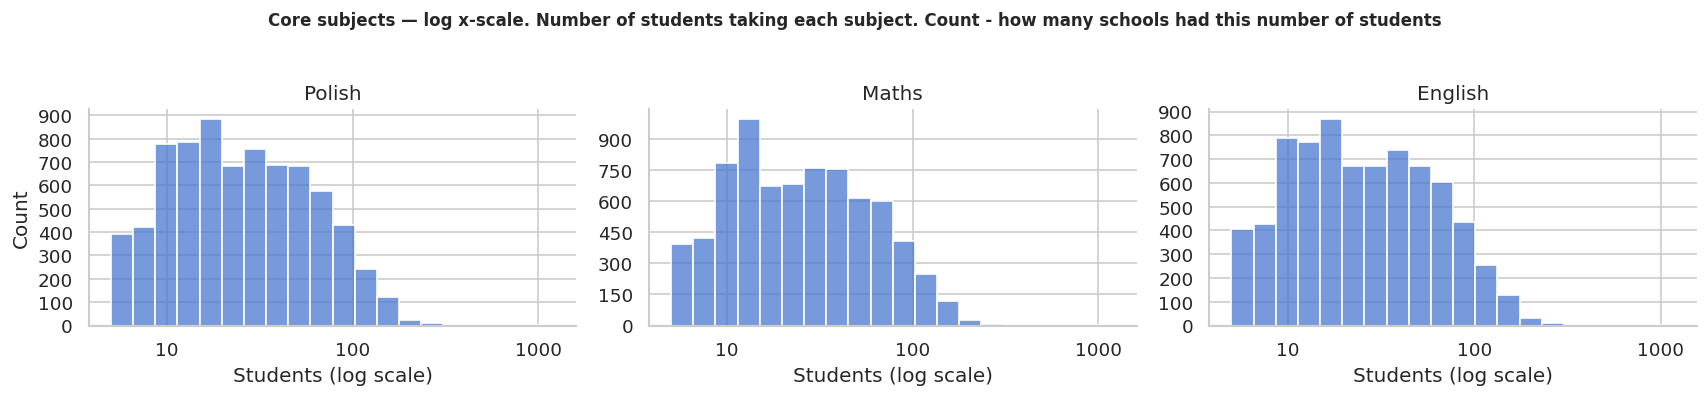

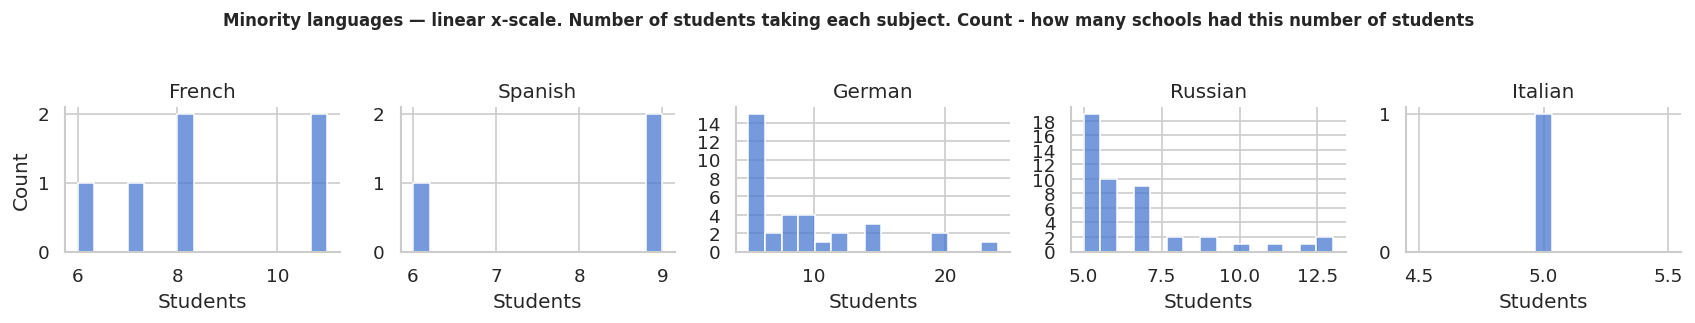


Minority languages — records with valid median data (n ≥ 5):


,School-year records,Median students,Max students
Subject,,,
French,6,8,11
Spanish,3,9,9
German,34,7,24
Russian,47,6,13
Italian,1,5,5


In [7]:
# ── Core subjects: log x-scale | Minority languages: linear x-scale ──────────
long_core = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in core_short if f'n_{s}' in df.columns
]).dropna()
long_core['Language'] = pd.Categorical(
    long_core['Language'],
    categories=[all_subjects_short[s] for s in core_short],
    ordered=True,
)

long_min = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in minority_short if f'n_{s}' in df.columns
]).dropna()
long_min['Language'] = pd.Categorical(
    long_min['Language'],
    categories=[all_subjects_short[s] for s in minority_short if f'n_{s}' in df.columns],
    ordered=True,
)

# Core — log x-scale
g1 = sns.FacetGrid(long_core, col='Language', col_wrap=3,
                   sharex=False, sharey=False, height=3.2, aspect=1.5)
g1.map(sns.histplot, 'Students', bins=20, log_scale=(True, False))
g1.set_titles('{col_name}')
g1.set_axis_labels('Students (log scale)', 'Count')
for ax in g1.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
g1.figure.suptitle('Core subjects — log x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(long_min, col='Language', col_wrap=5,
                  sharex=False, sharey=False, height=2.6, aspect=1.1)
g.map(sns.histplot, 'Students', bins=15)
g.set_titles('{col_name}')
g.set_axis_labels('Students', 'Count')
for ax in g.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.figure.suptitle('Minority languages — linear x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── Summary table for minority languages (only records with valid median, i.e. n ≥ 5) ──
rows = []
for subject_code in minority_short:
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    s = df.loc[df[f'median_{subject_code}'].notna(), col].dropna()
    if s.empty:
        continue
    rows.append({
        'Subject':             all_subjects_short[subject_code],
        'School-year records': len(s),
        'Median students':     int(s.median()),
        'Max students':        int(s.max()),
    })
print('\nMinority languages — records with valid median data (n ≥ 5):')
display(pd.DataFrame(rows).set_index('Subject'))

### Distribution of students count per school

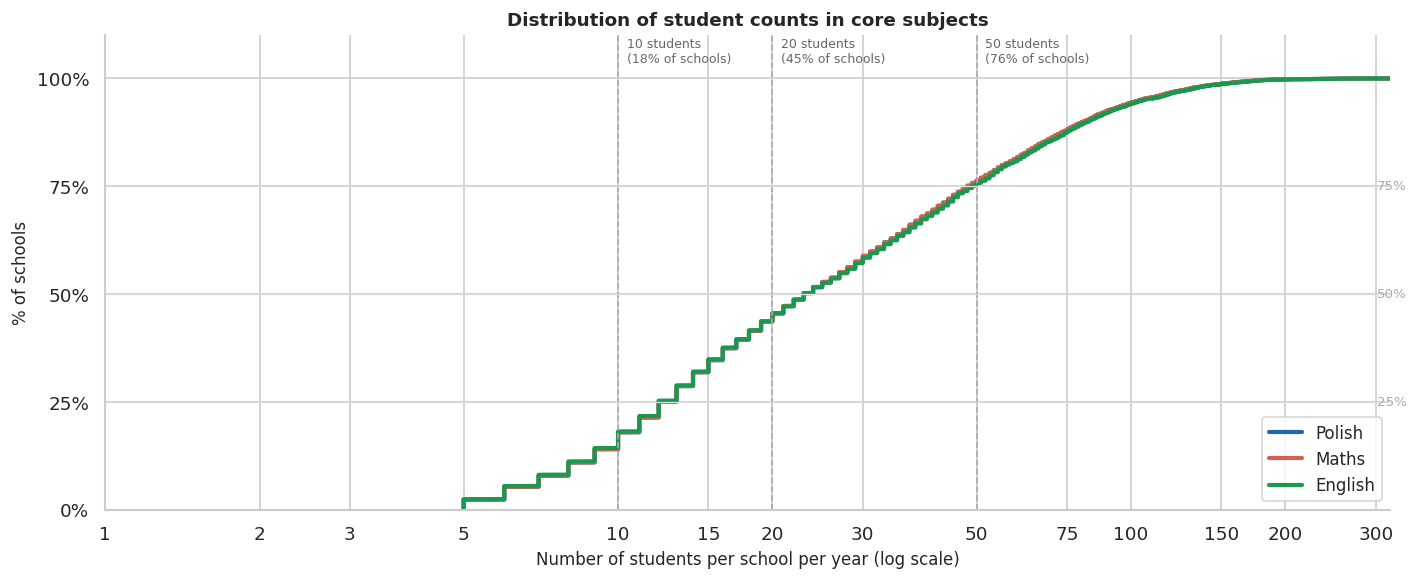

In [8]:
# ── ECDF for the 3 core subjects ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

core_colors = ['#2166ac', '#d6604d', '#1a9850']
for subject_code, color in zip(core_short, core_colors):
    col = f'n_{subject_code}'
    if col not in df.columns:
        continue
    x = np.sort(df[col].dropna().values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    ax.plot(x, y, label=all_subjects_short[subject_code], color=color, lw=2.5)

# Reference lines — percentages computed from actual n_polski distribution
_n_ref = df['n_polski'].dropna().values
for thresh in [10, 20, 50]:
    pct = ((_n_ref <= thresh).mean() * 100)
    ax.axvline(thresh, color='#aaa', ls='--', lw=1)
    ax.text(thresh * 1.04, 103,
            f'{thresh} students\n({pct:.0f}% of schools)',
            fontsize=7.5, color='#666', va='bottom')

for ref in [25, 50, 75]:
    ax.axhline(ref, color='#ddd', lw=0.8)
    ax.text(302, ref, f'{ref}%', fontsize=8, color='#aaa', va='center', ha='left')

ax.set_xscale('log')
ticks = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
ax.set_xticks(ticks)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim(1, 320)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.set_xlabel('Number of students per school per year (log scale)', fontsize=10)
ax.set_ylabel('% of schools', fontsize=10)
ax.set_title('Distribution of student counts in core subjects', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** Almost half of all schools have no more than 20 students sitting any given exam in any given year.
For around one fifth of schools, this number is not more than 10. This matters a lot for how we measure quality (couple good/bad students can strongly affect school results).

## 3. Choosing the best per-year metric

### The problem with raw scores

The exam difficulty changes year to year. In 2021, the voivodeship median for Maths was **46 pp**;
in 2022 it jumped to **60 pp**. A school scoring 55 pp in both years looks stable,
but in 2021 it was 9 pp *above* average and in 2022 it was 5 pp *below* average.
Raw scores alone can't tell us how a school is doing relative to its peers.

Below we show three views of the problem:
1. Year-to-year shifts in the voivodeship-wide distribution (next chart)
2. Why the median of medians jumps more than the mean of means (after that)
3. Within a single school, how much do results swing year to year? (after that)

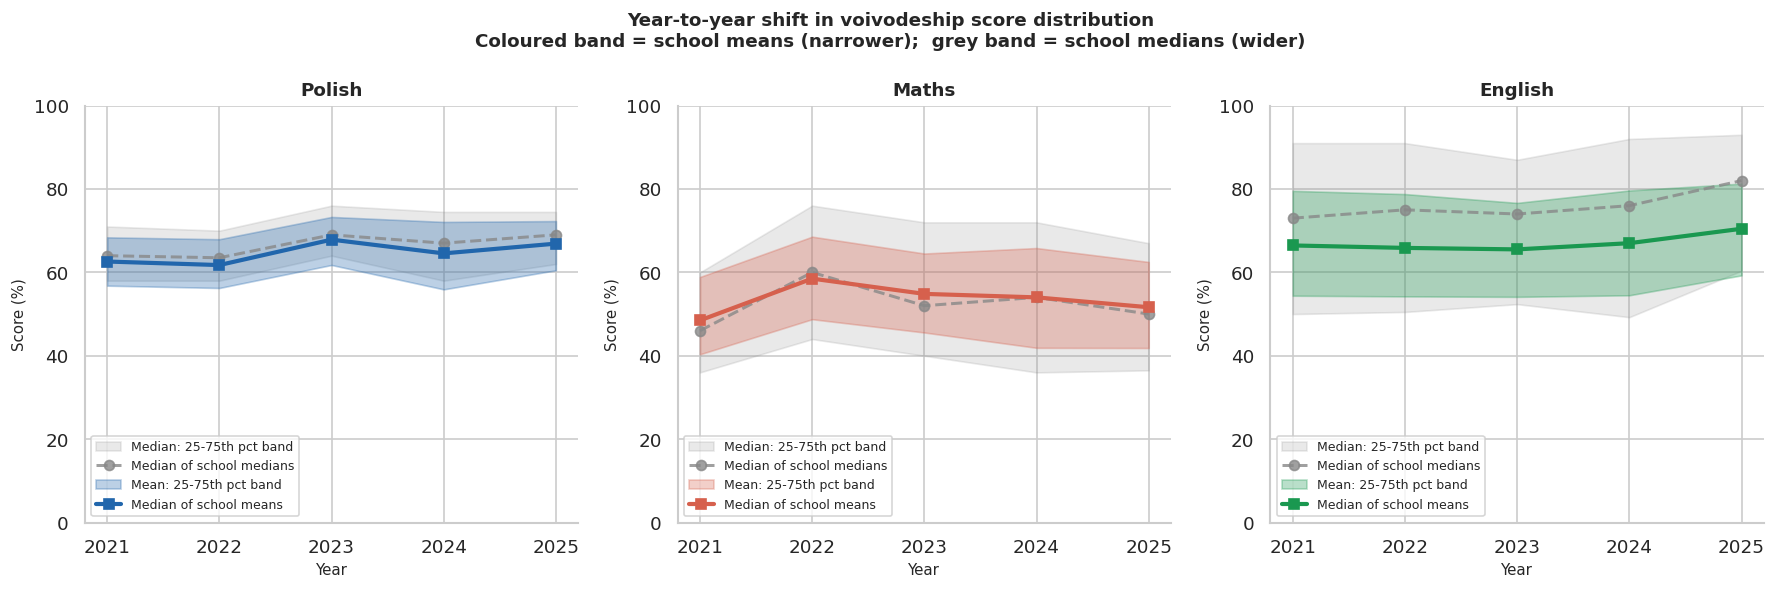

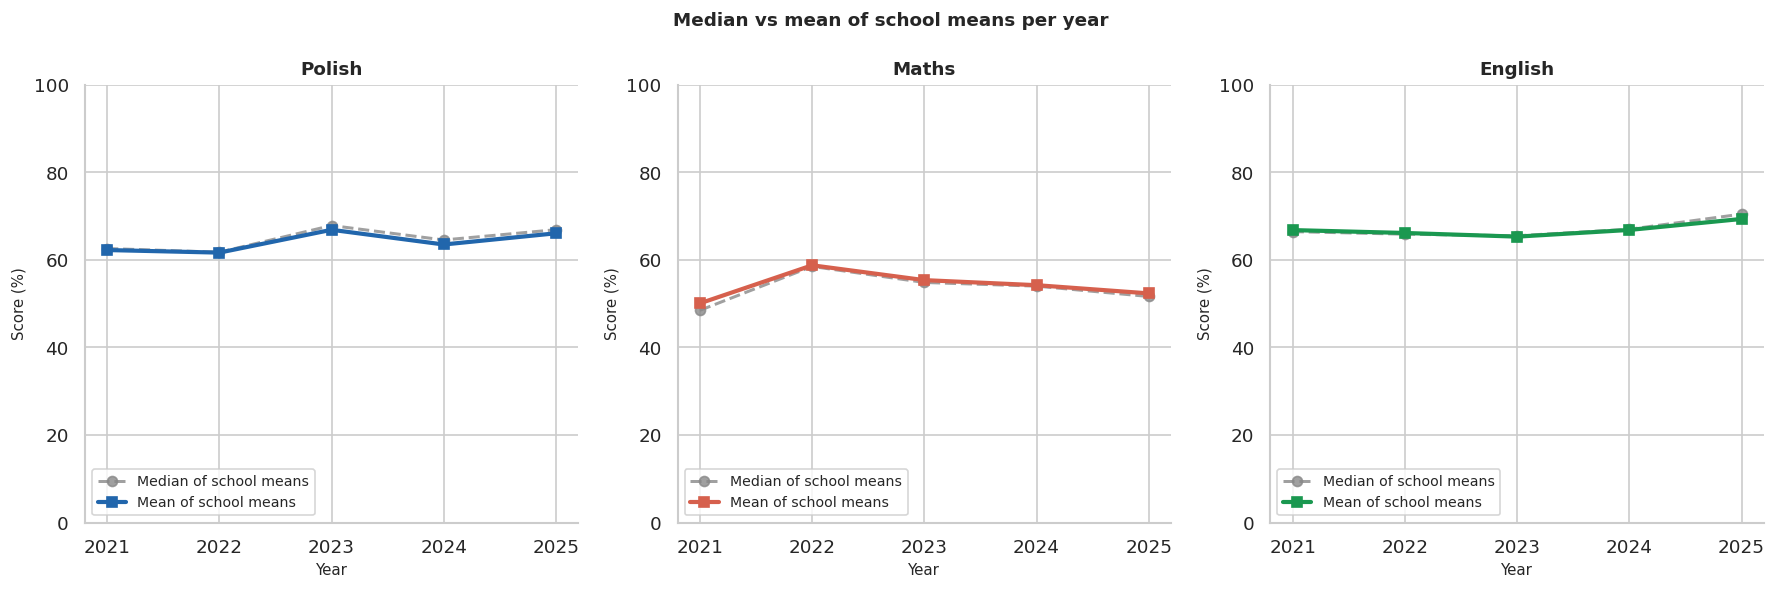

Median of school medians:


,Polish,Maths,English
year,,,
2021,64.0,46.0,73.0
2022,63.5,60.0,75.0
2023,69.0,52.0,74.0
2024,67.0,54.0,76.0
2025,69.0,50.0,82.0



Median of school means:


,Polish,Maths,English
year,,,
2021,62.6,48.5,66.5
2022,61.8,58.5,65.9
2023,67.9,54.8,65.5
2024,64.6,54.0,67.0
2025,66.9,51.6,70.5



Mean of school means:


,Polish,Maths,English
year,,,
2021,62.2,50.1,66.8
2022,61.7,58.8,66.1
2023,66.9,55.4,65.3
2024,63.5,54.2,66.8
2025,66.1,52.3,69.3



Year-to-year range (max - min across 5 years) -- smaller = more stable:


,Polish,Maths,English
Median of mediana range (pp),5.5,14.0,9.0
Mean of means range (pp),5.2,8.7,4.0


In [9]:
# Year-to-year voivodeship distribution: school medians (grey) vs school means (coloured)
years     = sorted(df['year'].unique())
n_years = len(years)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]

    grouped_median  = df.groupby('year')[f'median_{subject}']
    grouped_mean = df.groupby('year')[f'mean_{subject}']

    q25_median = grouped_median.quantile(0.25).values
    q50_median = grouped_median.quantile(0.50).values
    q75_median = grouped_median.quantile(0.75).values

    q25_avg = grouped_mean.quantile(0.25).values
    q50_avg = grouped_mean.quantile(0.50).values
    q75_avg = grouped_mean.quantile(0.75).values

    ax.fill_between(years, q25_median, q75_median, alpha=0.18, color='#888888',
                    label='Median: 25-75th pct band')
    ax.plot(years, q50_median, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school medians')
    ax.fill_between(years, q25_avg, q75_avg, alpha=0.30, color=color,
                    label='Mean: 25-75th pct band')
    ax.plot(years, q50_avg, 's-', lw=2.5, color=color,
            label='Median of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Year-to-year shift in voivodeship score distribution\n'
    'Coloured band = school means (narrower);  grey band = school medians (wider)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()
# Median of school means vs mean of school means
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subject in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subject]
    grouped_mean = df.groupby('year')[f'mean_{subject}']

    q50_avg  = grouped_mean.quantile(0.50).values
    mean_avg = grouped_mean.mean().values

    ax.plot(years, q50_avg, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school means')
    ax.plot(years, mean_avg, 's-', lw=2.5, color=color,
            label='Mean of school means')

    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(years)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Median vs mean of school means per year', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median of school medians:')
voivodeship_median_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'median_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_median_table.round(1))

print('\nMedian of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].median()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print('\nMean of school means:')
voivodeship_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].mean()
    for s in CORE_SUBJECTS
})
display(voivodeship_mean_table.round(1))

print(f'\nYear-to-year range (max - min across {n_years} years) -- smaller = more stable:')
median_range = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'median_{s}'].median().max()
    - df.groupby('year')[f'median_{s}'].median().min(), 1)
    for s in CORE_SUBJECTS}
mean_range = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'mean_{s}'].mean().max()
    - df.groupby('year')[f'mean_{s}'].mean().min(), 1)
    for s in CORE_SUBJECTS}
display(pd.DataFrame({'Median of mediana range (pp)': median_range,
                      'Mean of means range (pp)':   mean_range}).T)

#### Why does the median jumps more than mean?

1. If we consider only school means as expected when exam is easy (Polish, English) typically bad students push the mean down so mean is below median.
With hard subjects like Math situation is opposite - middle student has lower score so good students push mean higher than median.
We also see that in years were Math exam got easier the difference decreased.
2. But why median which in some settings is more stable than mean, here jumps way more?

**Why does the voivodeship median of medians in Maths jumps 14 pp while the voivodeship median of means moves only 10 pp?**

For Maths between 2021 and 2022, the voivodeship median of medians jumped from 46 to 60 (14 pp),
while the voivodeship median of means moved only from 48.5 to 58.5 (10 pp). What explains this 4 pp gap?

It's not random noise, and it's not just quantization (school medians come in 2 pp steps,
which can explain at most 1-2 pp of the jump). The real explanation requires looking
at how *individual* schools moved between the two years.

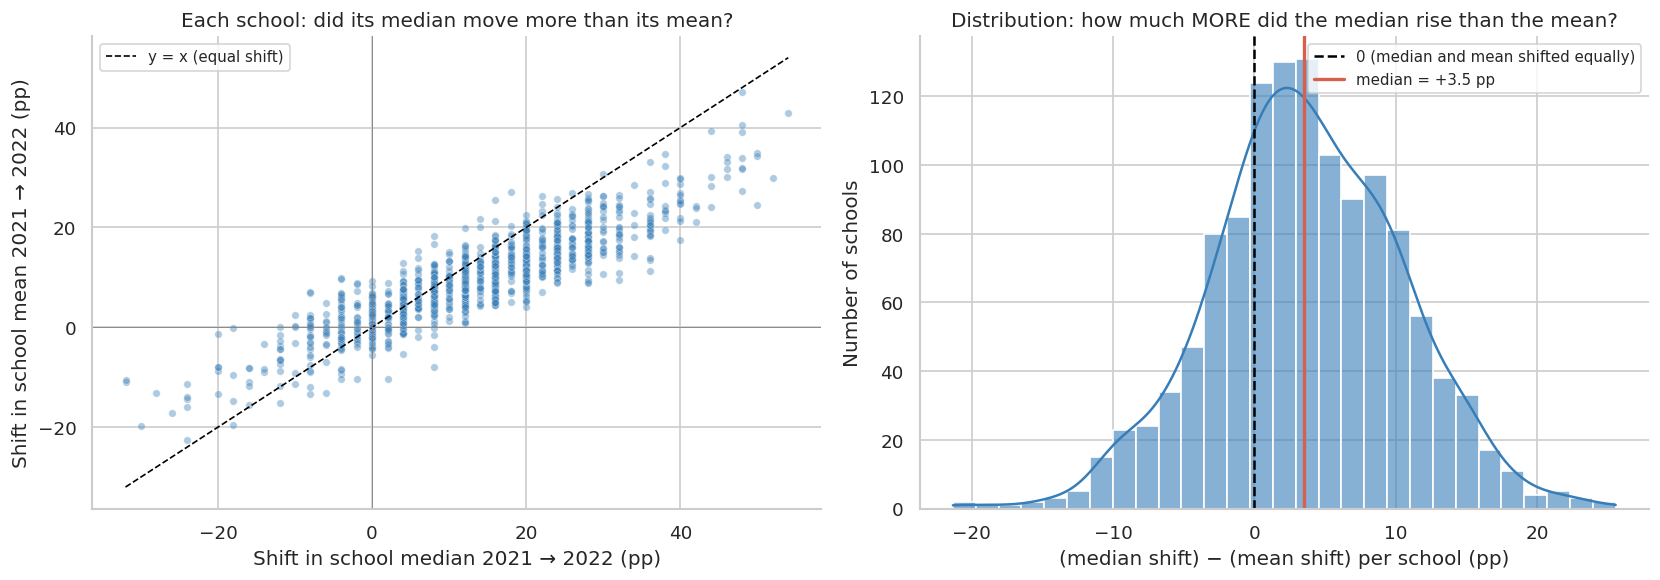

Schools tracked across 2021→2022: 1,247
Median shift in school medians: +14.0 pp
Median shift in school means:   +10.0 pp
Median of (median_shift − mean_shift): +3.5 pp
% schools where median rose more than mean: 71%


In [10]:
# Track the SAME schools across 2021 and 2022 — how much did each shift?
sub_2021 = df[df['year'] == 2021].set_index('rspo')
sub_2022 = df[df['year'] == 2022].set_index('rspo')
common = sub_2021.index.intersection(sub_2022.index)

median_shift = sub_2022.loc[common, 'median_matematyka'] - sub_2021.loc[common, 'median_matematyka']
shift_avg = sub_2022.loc[common, 'mean_matematyka']   - sub_2021.loc[common, 'mean_matematyka']
shift_math_df = pd.DataFrame({'median_shift': median_shift, 'shift_avg': shift_avg})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: shift in median vs shift in mean ---
ax = axes[0]
sns.scatterplot(data=shift_math_df, x='median_shift', y='shift_avg',
                ax=ax, alpha=0.4, s=20, color='#377eb8')

# Reference line y = x (where median and mean shifts would be equal)
x_min = min(shift_math_df.min().min(), -5)
x_max = max(shift_math_df.max().max(), 5)
ax.plot([x_min, x_max], [x_min, x_max], color='black', ls='--', lw=1,
        label='y = x (equal shift)')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Shift in school median 2021 → 2022 (pp)')
ax.set_ylabel('Shift in school mean 2021 → 2022 (pp)')
ax.set_title('Each school: did its median move more than its mean?')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Most points sit BELOW the y=x line → median rose more than the mean

# --- Histogram: median shift minus mean shift ---
ax = axes[1]
diff = median_shift - shift_avg
sns.histplot(diff, kde=True, ax=ax, color='#377eb8', alpha=0.6)
ax.axvline(0, color='black', ls='--', lw=1.5,
           label='0 (median and mean shifted equally)')
ax.axvline(diff.median(), color='#d6604d', lw=2,
           label=f'median = {diff.median():+.1f} pp')
ax.set_xlabel('(median shift) − (mean shift) per school (pp)')
ax.set_ylabel('Number of schools')
ax.set_title('Distribution: how much MORE did the median rise than the mean?')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Numeric summary
print(f'Schools tracked across 2021→2022: {len(common):,}')
print(f'Median shift in school medians: {median_shift.median():+.1f} pp')
print(f'Median shift in school means:   {shift_avg.median():+.1f} pp')
print(f'Median of (median_shift − mean_shift): {(median_shift - shift_avg).median():+.1f} pp')
print(f'% schools where median rose more than mean: {((median_shift - shift_avg) > 0).mean()*100:.0f}%')

#### How did individual schools move 2021 → 2022?

**Left:** Each dot is one school. The X-axis is how much that school's median moved
between 2021 and 2022. The Y-axis is how much its mean moved. If both metrics
captured the same thing, dots would sit on the dashed y = x line.

The dots sit consistently *below* the line — meaning for almost every school, the
median rose **more** than the mean. The exam got easier, but the median student
benefited more than the average student.

**Right:** The same fact shown as a distribution. We plot (median shift) − (mean shift)
for each school. If this difference were near zero, the two metrics would behave
similarly. Instead the distribution is clearly shifted to the right of zero —
the median rose about 4 pp more than the mean for the typical school.

**Why does this happen?**

The mean averages over the whole class, including students at both extremes.
When the exam got easier, the strong students were already near 90–100% — they
couldn't gain as much (ceiling effect). The mean reflects this dampening.

The median is the score of the *middle* student. When the difficulty shifts,
this middle student's score moves by the full amount of the shift, because they
weren't pressed against the ceiling. So the median captures the shift in full,
the mean captures it after ceiling/floor effects dampen the extremes.

**Implication for the metric:**

The voivodeship mean is a more *linear* function of exam difficulty than the
voivodeship median — it absorbs ceiling and floor effects proportionally.
Subtracting the voivodeship mean from each school's mean (`diff_mean`) gives a
cleaner residual signal about that school's performance, relative to the
voivodeship in that year. Subtracting the voivodeship median (`diff_median`) leaves
residuals contaminated by the non-linear response of the median to difficulty
shifts. This is one more reason `diff_mean` beats `diff_median` in LOO stability.

#### How much does a single school swing year to year?

So far we looked at the voivodeship-wide distribution. Now: when we follow a
single school through 3+ years, how much does its result move?
And does the median or mean swing more *within a single school*?

This matters because it sets a floor on how precise our ranking can be: if a typical
school's median moves by 24 pp year to year, then a 5 pp difference between two
schools is comfortably within the noise.

Within-school year-to-year range of mean score (pp), schools with >= 3 years:
voi_range = voivodeship-wide year-to-year range (baseline).



,voi_range (pp),P25 (pp),P50 (pp),P75 (pp),P90 (pp),P95 (pp)
subject,,,,,,
Polish,5.2,9.1,12.9,18.1,23.5,26.1
Maths,8.7,11.9,16.3,22.4,29.3,34.1
English,4.0,8.4,13.2,19.7,27.7,33.0


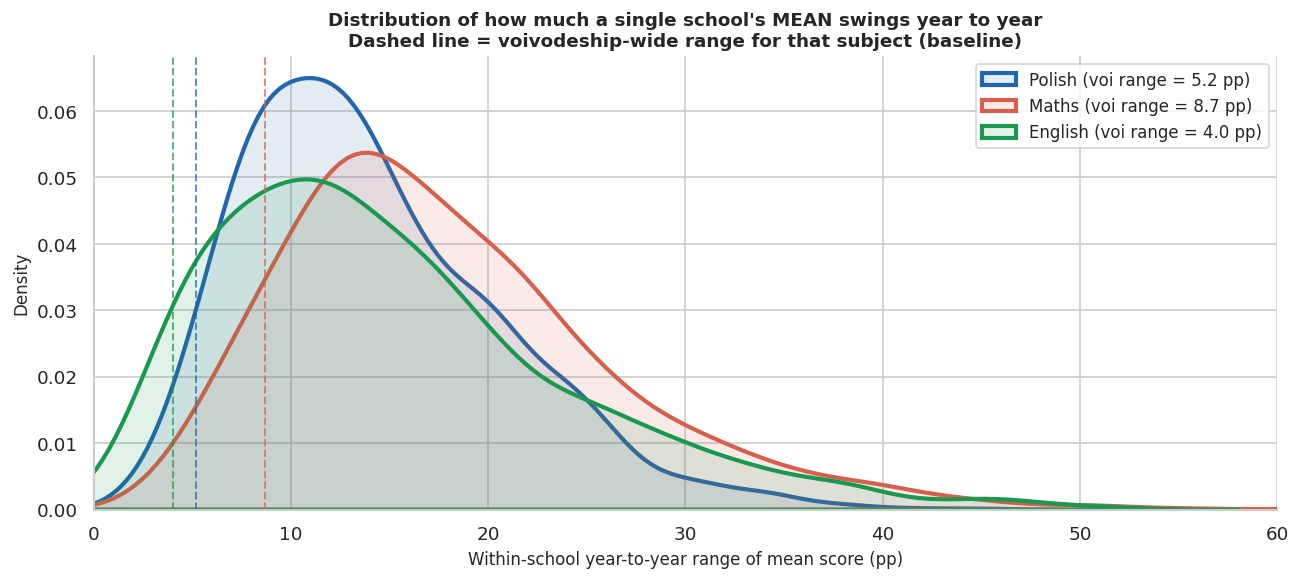

In [11]:
# ── Within-school year-to-year variation of the school mean ──────────────────
# Schools with >= 3 years of data give meaningful range/std.
# We focus on the mean since diff_mean / unit_norm_diff_mean won the LOO test.
year_count_for_swing = df.groupby('rspo')['year'].nunique()
df_swing = df[df['rspo'].isin(year_count_for_swing[year_count_for_swing >= 3].index)].copy()

# Per-school range (max - min) of mean score across the school's years
swing_records = []
for subject in core_short:
    mean_range = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min())
    voi_avg_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                     - df.groupby('year')[f'mean_{subject}'].mean().min())
    row = {
        'subject':         SUBJECT_LABELS[subject],
        'voi_range (pp)':  round(voi_avg_range, 1),
    }
    for pct in [25, 50, 75, 90, 95]:
        row[f'P{pct} (pp)'] = round(np.percentile(mean_range.dropna(), pct), 1)
    swing_records.append(row)

swing_df = pd.DataFrame(swing_records).set_index('subject')
print("Within-school year-to-year range of mean score (pp), schools with >= 3 years:")
print("voi_range = voivodeship-wide year-to-year range (baseline).\n")
display(swing_df)

# ── Distribution of within-school mean range, per subject ───────────────────
# How wide is the band of mean-score swings for each subject?
fig, ax = plt.subplots(figsize=(11, 5))

for subject in core_short:
    rng = df_swing.groupby('rspo')[f'mean_{subject}'].agg(lambda x: x.max() - x.min()).dropna()
    voi_range = (df.groupby('year')[f'mean_{subject}'].mean().max()
                 - df.groupby('year')[f'mean_{subject}'].mean().min())

    sns.kdeplot(rng, ax=ax, color=SUBJECT_COLORS[subject], lw=2.5,
                label=f'{SUBJECT_LABELS[subject]} (voi range = {voi_range:.1f} pp)',
                fill=True, alpha=0.12)

    # Mark the voivodeship-wide range as a vertical line in matching colour
    ax.axvline(voi_range, color=SUBJECT_COLORS[subject], lw=1.2, ls='--', alpha=0.7)

ax.set_xlabel('Within-school year-to-year range of mean score (pp)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title(
    'Distribution of how much a single school\'s MEAN swings year to year\n'
    'Dashed line = voivodeship-wide range for that subject (baseline)',
    fontsize=11, fontweight='bold')
ax.set_xlim(0, 60)
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the table shows:**

- **Single schools swing 1.7–2.6x more than the voivodeship-wide trend.** For the median
  school in Maths, results move 24 pp year to year, while the voivodeship-wide median
  moves 14 pp. Schools are individually noisier than the trend.
- **Maths has the smallest school/voivodeship ratio (1.7x at P50)**, despite the largest
  voivodeship swing (14 pp). This means much of the Maths year-to-year movement
  is "everybody shifted together" (driven by exam difficulty), not individual school
  variation. After we normalise by the voivodeship reference, Maths becomes much cleaner.
- **Polish and English ratios are 2.3-2.6x at P50 and reach 5.6-5.9x at P95.** Schools
  in these subjects are much more individually noisy than the voivodeship-wide trend.
- **Median swings more than mean inside each school.** For Maths the typical school
  median range is 24 pp vs 16 pp for the mean (47% wider); for English 21 vs 13 pp
  (59% wider). This is the same effect we saw in the 2021→2022 example — the median
  responds more aggressively to year-to-year changes in difficulty and cohort.

**Concrete example.** A "median" school in Maths has its full-data score somewhere
around the 50th percentile of the ranking — let's say its 5-year mean score is 52 pp.
With a year-to-year range of 24 pp, its best year might show 64 pp (~ 80th percentile)
and its worst year might show 40 pp (~ 20th percentile). The school's "true" position
in the ranking is anywhere across a 60-percentile-wide band depending on which year
you happen to look at.

**Implication:** We need a metric that *normalises by year* to subtract off most of
this voivodeship-wide noise, and we need to *aggregate across multiple years* to reduce
the within-school cohort noise. A single-year ranking will be dominated by luck.

**Real schools — examples of year-to-year swings**

To make the numbers concrete, let's pick a few real schools from the dataset
and look at how their mean score moved year by year. We sample across the
range of swing magnitudes — calm schools, typical schools, and very volatile ones.

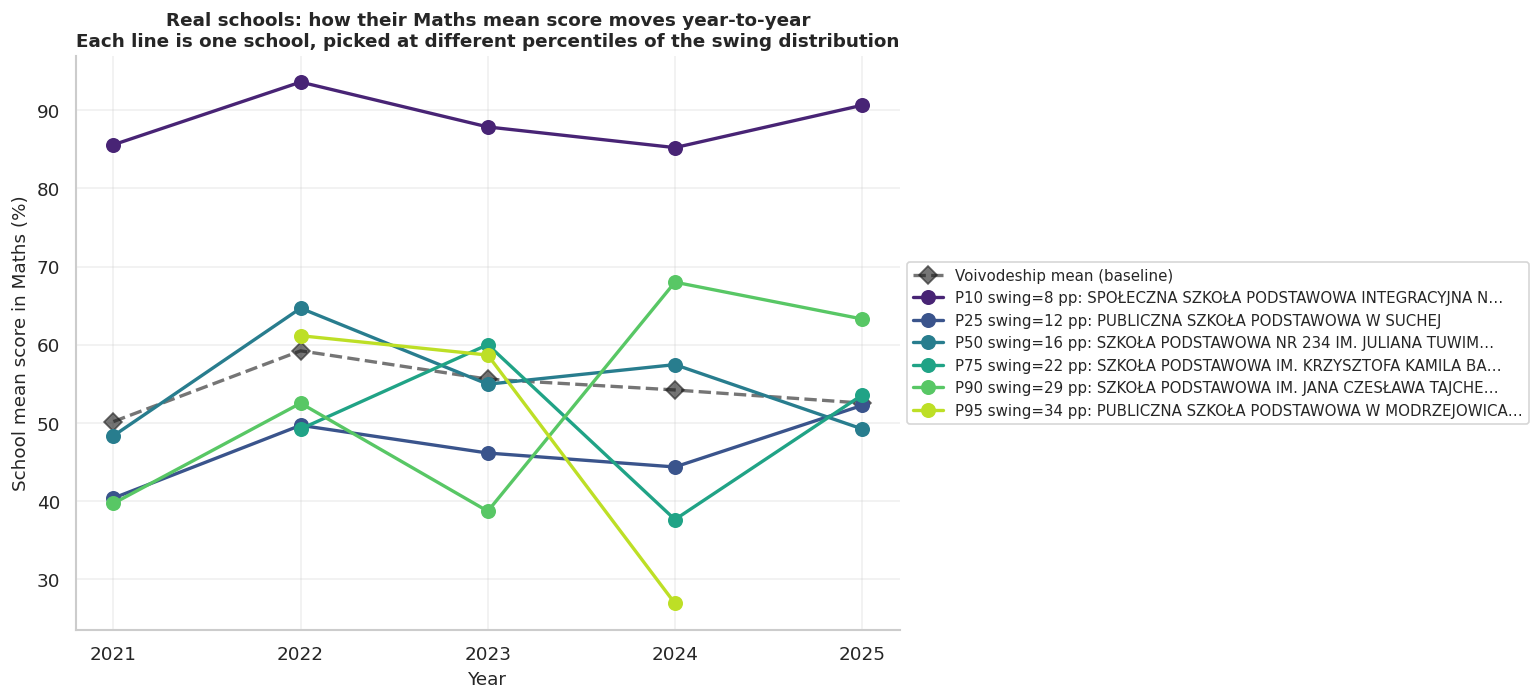


Table of the picked schools:


,school_name,n_years,min_mean,max_mean,swing (pp),mean_n_students
percentile,,,,,,
P10,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 10...,5,85.2,93.6,8.4,25.8
P25,PUBLICZNA SZKOŁA PODSTAWOWA W SUCHEJ,5,40.3,52.2,11.9,20.4
P50,SZKOŁA PODSTAWOWA NR 234 IM. JULIANA TUWIMA,5,48.3,64.7,16.3,47.4
P75,SZKOŁA PODSTAWOWA IM. KRZYSZTOFA KAMILA BACZYŃ...,4,37.6,60.0,22.4,8.2
P90,SZKOŁA PODSTAWOWA IM. JANA CZESŁAWA TAJCHERTA ...,5,38.7,68.0,29.3,10.2
P95,PUBLICZNA SZKOŁA PODSTAWOWA W MODRZEJOWICACH,3,26.9,61.1,34.3,6.7


In [12]:
# ── Concrete examples: real schools with various swing magnitudes ────────────
# Compute swing per school (Maths)
SUBJ_FOR_EXAMPLES = 'matematyka'
rng_per_school = (
    df_swing.groupby('rspo')[f'mean_{SUBJ_FOR_EXAMPLES}']
    .agg(lambda x: x.max() - x.min())
    .dropna()
    .sort_values()
)

n_total = len(rng_per_school)

# Pick representative schools at given percentile positions
PICK_PCTS = [10, 25, 50, 75, 90, 95]
picks = []
for p in PICK_PCTS:
    idx_pos = int(n_total * p / 100)
    rspo = rng_per_school.index[idx_pos]
    picks.append((p, rspo, rng_per_school.iloc[idx_pos]))

# Plot each school's mean trajectory across years
fig, ax = plt.subplots(figsize=(13, 6))

years_all = sorted(df_swing['year'].unique())
voi_mean_per_year = df_swing.groupby('year')[f'mean_{SUBJ_FOR_EXAMPLES}'].mean()
ax.plot(years_all, voi_mean_per_year.values, 'k--', lw=2,
        marker='D', markersize=8, label='Voivodeship mean (baseline)', alpha=0.6)

cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(picks)))
for (pct, rspo, swing), color in zip(picks, cmap):
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    name = school_data['school_name'].iloc[0]
    # Truncate long names
    name_short = name[:42] + '…' if len(name) > 42 else name
    ax.plot(school_data['year'], school_data[f'mean_{SUBJ_FOR_EXAMPLES}'],
            marker='o', lw=2, color=color, markersize=8,
            label=f'P{pct} swing={swing:.0f} pp: {name_short}')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(f'School mean score in {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} (%)', fontsize=11)
ax.set_title(
    f'Real schools: how their {SUBJECT_LABELS[SUBJ_FOR_EXAMPLES]} mean score moves year-to-year\n'
    f'Each line is one school, picked at different percentiles of the swing distribution',
    fontsize=11, fontweight='bold')
ax.set_xticks(years_all)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table summary
print('\nTable of the picked schools:')
rows = []
for pct, rspo, swing in picks:
    school_data = df_swing[df_swing['rspo'] == rspo].sort_values('year')
    rows.append({
        'percentile': f'P{pct}',
        'school_name': school_data['school_name'].iloc[0],
        'n_years': len(school_data),
        'min_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].min(), 1),
        'max_mean': round(school_data[f'mean_{SUBJ_FOR_EXAMPLES}'].max(), 1),
        'swing (pp)': round(swing, 1),
        'mean_n_students': round(school_data[f'n_{SUBJ_FOR_EXAMPLES}'].mean(), 1),
    })
display(pd.DataFrame(rows).set_index('percentile'))

## Picking the best metric — LOO stability test

We now have to choose *which* per-year metric to use as our normalised score.
Below are the candidates. For each school in each year we can compute:

| Metric | Description |
|--------|-------------|
| `mean` | Average student score |
| `median` | Middle student's score (less sensitive to outliers) |
| `diff_mean` | School mean - voivodeship mean for that year |
| `diff_median` | School median - voivodeship median for that year |
| `unit_norm_diff_mean` | `diff_mean` divided by the distance to the ceiling (if positive) or floor (if negative). Result in [-1, +1] |
| `unit_norm_diff_median` | Same logic using `diff_median` |
| `pct_mean` | Percentile rank of the school mean in that year (across all schools) |
| `pct_median` | Percentile rank of the school median in that year |

## How we choose

We use **jackknife (leave-one-out) stability**: for a school with N years of data,
we compute the metric N times, each time leaving out one year. The more the result
changes, the less stable the metric — and a less stable metric means the score is
driven by luck (which year happened to be included) rather than real school quality.

We want the metric where the N estimates are *closest together* — measured by the
**LOO standard deviation**, normalised by the metric's overall spread across all
schools, so that metrics on different scales can be compared.

In [13]:
# Compute voivodeship median per year per subject (used for diff_median)
voivodeship_median = {}
for subject_code in core_short:
    voivodeship_median[subject_code] = df.groupby('year')[f'median_{subject_code}'].median()
    df[f'voivodeship_median_{subject_code}'] = df['year'].map(voivodeship_median[subject_code])
    df[f'diff_median_{subject_code}'] = df[f'median_{subject_code}'] - df[f'voivodeship_median_{subject_code}']

# Compute percentile ranks within each year for mean and median
for subject_code in core_short:
    for metric in ['median', 'mean']:
        input_column  = f'{metric}_{subject_code}'
        output_column = f'pct_{metric}_{subject_code}'
        df[output_column] = df.groupby('year')[input_column].transform(
            lambda x: stats.rankdata(x.fillna(x.median()), method='average') / len(x) * 100
        )

# ── Compute additional candidate metrics: diff_mean, unit_norm_diff_mean, unit_norm_diff_median ─
voivodeship_mean = {}
for subject in core_short:
    voivodeship_mean[subject] = df.groupby('year')[f'mean_{subject}'].mean()
    df[f'voivodeship_mean_{subject}'] = df['year'].map(voivodeship_mean[subject])
    df[f'diff_mean_{subject}'] = df[f'mean_{subject}'] - df[f'voivodeship_mean_{subject}']

    # unit_norm_diff: signed normalisation to [-1, +1] using ceiling/floor distance
    # unit_norm_diff_mean uses mean-based diff and voivodeship mean as reference
    d_avg = df[f'diff_mean_{subject}']
    v_avg = df[f'voivodeship_mean_{subject}']
    df[f'unit_norm_diff_mean_{subject}'] = np.where(
        d_avg >= 0,
        d_avg / (100 - v_avg).where(100 - v_avg > 0, 1),
        d_avg / v_avg.where(v_avg > 0, 1),
    )

    # unit_norm_diff_median uses median-based diff and voivodeship median as reference
    median_diffs = df[f'diff_median_{subject}']
    median_values = df[f'voivodeship_median_{subject}']
    df[f'unit_norm_diff_median_{subject}'] = np.where(
        median_diffs >= 0,
        median_diffs / (100 - median_values).where(100 - median_values > 0, 1),
        median_diffs / median_values.where(median_values > 0, 1),
    )

print('Candidate metrics computed for each (school, year, subject) row:')
print('  diff_median, diff_mean, pct_mean, pct_median, unit_norm_diff_mean, unit_norm_diff_median')
print('(mean, median already exist from earlier cells)')

Candidate metrics computed for each (school, year, subject) row:
  diff_median, diff_mean, pct_mean, pct_median, unit_norm_diff_mean, unit_norm_diff_median
(mean, median already exist from earlier cells)


In [14]:
# ── LOO fold scores DataFrame ─────────────────────────────────────────────────
# One row per (rspo, year_subset, aggregation_method).
#
# year_subset: sorted tuple of years included in the fold.
# all_school_years_used: True when year_subset equals all years the school has data in.
#
# Four fold types generated per school:
#   full     — all years available for the school
#   loo_all  — leave-one-out over all N dataset years (schools with data in all N years only)
#   loo_2022 — leave-one-out over years ≥ 2022 (schools with complete data from 2022 onward)
#   single   — one fold per individual year the school has data
#
# Aggregation methods applied across per-year metric values within each fold:
#   mean                                 — arithmetic mean (equal weight per year)
#   mean_weighted_by_students_count      — weighted mean, weight = n_students per year
#   mean_weighted_by_students_count_sqrt — weighted mean, weight = sqrt(n_students)
#   median                               — median of per-year values
#   trimmed_mean                         — drop the single best and worst year, mean of the rest;
#                                          n=1 → raw value; n=2 → arithmetic mean
#
# n_{subject} columns: median of per-year student counts across years in the fold.
# Median is used (not mean) so a single outlier year does not distort the size summary.

CANDIDATE_METRICS = {
    'mean':               lambda s: f'mean_{s}',
    'median':             lambda s: f'median_{s}',
    'diff_mean':          lambda s: f'diff_mean_{s}',
    'diff_median':        lambda s: f'diff_median_{s}',
    'unit_norm_diff_mean':   lambda s: f'unit_norm_diff_mean_{s}',
    'unit_norm_diff_median': lambda s: f'unit_norm_diff_median_{s}',
    'pct_mean':           lambda s: f'pct_mean_{s}',
    'pct_median':         lambda s: f'pct_median_{s}',
}


ALL_YEARS  = sorted(df['year'].unique())
YEARS_2022 = [y for y in ALL_YEARS if y >= 2022]
N_YEARS    = len(ALL_YEARS)

rspo_all_years = {
    rspo for rspo, grp in df.groupby('rspo')
    if set(grp['year'].unique()) == set(ALL_YEARS)
}
rspo_from_2022 = {
    rspo for rspo, grp in df.groupby('rspo')
    if set(YEARS_2022).issubset(set(grp['year'].unique()))
}

print(f'Dataset years: {ALL_YEARS}')
print(f'Schools with all {N_YEARS} years:              {len(rspo_all_years):,}')
print(f'Schools with all years from 2022 ({len(YEARS_2022)} yrs): {len(rspo_from_2022):,}')

AGG_METHODS = [
    'mean',
    'mean_weighted_by_students_count',
    'mean_weighted_by_students_count_sqrt',
    'median',
    'trimmed_mean',
]

from typing import NamedTuple


class NanPropagationMasks(NamedTuple):
    """Per (fold, kolumna) flagi reprodukujące regułę NaN z _aggregate."""
    metric_has_any_nan: pd.DataFrame
    students_count_has_any_nan: pd.DataFrame
    students_count_sums: pd.DataFrame
    students_count_sum_is_zero: pd.DataFrame


LEADING_COLUMNS = ['rspo', 'years', 'aggregation_method', 'all_school_years_used']


# ── 1. Specyfikacja fold'ów ────────────────────────────────────────────────
def _build_fold_specifications(
    source_df: pd.DataFrame,
    rspo_all_years: set,
    rspo_from_2022: set,
    all_years: tuple,
    years_2022: tuple,
) -> pd.DataFrame:
    """
    Buduje listę fold'ów do policzenia.

    Zwraca DataFrame z kolumnami:
    - rspo:                  identyfikator szkoły
    - years:                 tuple lat należących do fold'a
    - all_school_years_used: czy fold pokrywa wszystkie lata szkoły
    - fold_id:               unikalny int per (rspo, years), nadawany kolejno.
                             Używany później jako klucz grupowania w groupby —
                             szybszy niż (rspo, years), bo tuple jako klucz
                             groupby jest wolny.

    Jeden wiersz per (szkoła, podzbiór lat). Zawiera:
    - fold pełny (wszystkie lata, dla których szkoła ma dane),
    - LOO po ALL_YEARS  (tylko dla szkół w rspo_all_years),
    - LOO po YEARS_2022 (tylko dla szkół w rspo_from_2022),
    - fold'y jednoroczne dla każdego roku posiadanego przez szkołę.
    """
    school_years_map = (
        source_df.groupby('rspo')['year']
                 .apply(lambda values: tuple(sorted(values.unique())))
                 .to_dict()
    )

    loo_all_years_folds = [
        tuple(year for year in all_years if year != excluded_year)
        for excluded_year in all_years
    ]
    loo_from_2022_folds = [
        tuple(year for year in years_2022 if year != excluded_year)
        for excluded_year in years_2022
    ]

    fold_records = []
    for rspo, school_years in school_years_map.items():
        school_years_set = set(school_years)
        seen_folds = {school_years}
        fold_records.append((rspo, school_years, True))  # fold pełny

        candidate_folds: list[tuple] = []
        if rspo in rspo_all_years:
            candidate_folds.extend(loo_all_years_folds)
        if rspo in rspo_from_2022:
            candidate_folds.extend(loo_from_2022_folds)
        candidate_folds.extend((year,) for year in school_years)

        for fold in candidate_folds:
            if fold not in seen_folds:
                seen_folds.add(fold)
                all_school_years_used = set(fold) == school_years_set
                fold_records.append((rspo, fold, all_school_years_used))

    fold_specifications = pd.DataFrame(
        fold_records, columns=['rspo', 'years', 'all_school_years_used']
    )
    fold_specifications['fold_id'] = np.arange(len(fold_specifications), dtype=np.int64)
    return fold_specifications


# ── 2. Eksplozja do formatu long + join z df ──────────────────────────────
def _explode_folds_to_long_format(
    fold_specifications: pd.DataFrame,
    source_df: pd.DataFrame,
    metric_columns: list[str],
    students_count_columns: list[str],
) -> pd.DataFrame:
    """
    Rozkłada każdy fold na N wierszy (po jednym per rok) i dołącza dane z df.

    Wejście:           jeden wiersz per fold, kolumna 'years' = tuple lat.
    Wyjście (long):    jeden wiersz per (fold_id, year), wzbogacony o metryki
                       i liczby uczniów z source_df dla danego (rspo, year).

    Przykład: fold (rspo=123, years=(2021, 2022, 2023)) → 3 wiersze, każdy
    z innym rokiem i metrykami dla tego roku. To pozwala potem zrobić
    groupby('fold_id') i policzyć agregaty wektorowo.
    """
    folds_long = (
        fold_specifications[['fold_id', 'rspo', 'years']]
            .explode('years', ignore_index=True)
            .rename(columns={'years': 'year'})
    )
    folds_long['year'] = folds_long['year'].astype(source_df['year'].dtype)

    merged = folds_long.merge(
        source_df[['rspo', 'year'] + metric_columns + students_count_columns],
        on=['rspo', 'year'],
        how='left',
    )
    assert len(merged) == len(folds_long), (
        f'Merge zmienił liczbę wierszy: {len(folds_long)} → {len(merged)} '
        f'(prawdopodobnie brakujące (rspo, year) w df).'
    )
    return merged


# ── 3. Maski NaN ──────────────────────────────────────────────────────────
def _compute_nan_propagation_masks(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    students_count_columns: list[str],
) -> NanPropagationMasks:
    """
    Liczy flagi reprodukujące regułę NaN z _aggregate.

    Parametry:
    - merged_long:   DataFrame z _explode_folds_to_long_format — jeden wiersz
                     per (fold_id, year), z metrykami i n_subject z source_df.
    - fold_grouper:  Series z fold_id (= merged_long['fold_id']) używana jako
                     klucz grupowania. Wydzielona raz, żeby nie powtarzać
                     lookupu kolumny przy każdym groupby.

    Dlaczego to potrzebne:
    Pandas w groupby().mean()/sum()/median() domyślnie POMIJA NaN-y,
    a _aggregate je propaguje (zwraca NaN gdy jakiekolwiek wejście to NaN
    albo gdy n.sum() == 0). Te maski służą do naprawy tego rozjazdu
    przez _apply_nan_propagation_mask po policzeniu agregatów.

    Zwraca cztery DataFrame'y indeksowane fold_id, każdy z kolumnami
    odpowiadającymi metric_columns lub students_count_columns.
    """
    metric_has_any_nan = (
        merged_long[metric_columns].isna().groupby(fold_grouper).any()
    )
    students_count_has_any_nan = (
        merged_long[students_count_columns].isna().groupby(fold_grouper).any()
    )
    students_count_sums = (
        merged_long[students_count_columns]
            .groupby(fold_grouper)
            .sum(min_count=1)
    )
    students_count_sum_is_zero = (students_count_sums == 0)

    return NanPropagationMasks(
        metric_has_any_nan=metric_has_any_nan,
        students_count_has_any_nan=students_count_has_any_nan,
        students_count_sums=students_count_sums,
        students_count_sum_is_zero=students_count_sum_is_zero,
    )


# ── 4. Mediana liczby uczniów ──────────────────────────────────────────────
def _compute_median_students_per_fold(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    students_count_columns: list[str],
    students_count_has_any_nan: pd.DataFrame,
) -> pd.DataFrame:
    """
    Mediana n_subject w obrębie fold'a, z semantyką np.median:
    jakikolwiek NaN na wejściu → NaN. Pandas domyślnie pomija NaN,
    więc nakładamy ręcznie maskę po policzeniu mediany.
    """
    median_students = (
        merged_long[students_count_columns].groupby(fold_grouper).median()
    )
    for column in students_count_columns:
        median_students.loc[students_count_has_any_nan[column], column] = np.nan
    return median_students


# ── 5. Pięć metod agregacji ────────────────────────────────────────────────
def _aggregate_arithmetic_mean(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """Zwykła średnia arytmetyczna metryk per fold."""
    return merged_long[metric_columns].groupby(fold_grouper).mean()


def _aggregate_arithmetic_median(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """Mediana metryk per fold."""
    return merged_long[metric_columns].groupby(fold_grouper).median()


def _aggregate_trimmed_mean(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
) -> pd.DataFrame:
    """
    Dla n ≥ 3: średnia po odrzuceniu min i max → (sum - min - max) / (count - 2).
    Dla n ∈ {1, 2}: zwykła średnia (zgodnie z _aggregate).
    """
    grouped = merged_long[metric_columns].groupby(fold_grouper)
    metric_sums = grouped.sum(min_count=1)
    metric_counts = grouped.count()
    metric_minimums = grouped.min()
    metric_maximums = grouped.max()

    counts_as_float = metric_counts.astype(float)
    trimmed = (metric_sums - metric_minimums - metric_maximums) / (
        counts_as_float - 2
    ).replace(0, np.nan)
    mean_fallback = metric_sums / counts_as_float.replace(0, np.nan)
    return trimmed.where(metric_counts >= 3, mean_fallback)


def _aggregate_weighted_mean_by_count(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    metric_column_to_subject: dict[str, str],
    students_count_sums: pd.DataFrame,
) -> pd.DataFrame:
    """Σ(metric · n) / Σ(n), gdzie n to liczba uczniów odpowiedniego przedmiotu."""
    weighted_metric_per_row = pd.DataFrame(index=merged_long.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        weighted_metric_per_row[column] = merged_long[column] * merged_long[f'n_{subject}']

    weighted_metric_sums = (
        weighted_metric_per_row.groupby(fold_grouper).sum(min_count=1)
    )

    result = pd.DataFrame(index=weighted_metric_sums.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        result[column] = (
            weighted_metric_sums[column]
            / students_count_sums[f'n_{subject}'].replace(0, np.nan)
        )
    return result


def _aggregate_weighted_mean_by_sqrt_count(
    merged_long: pd.DataFrame,
    fold_grouper: pd.Series,
    metric_columns: list[str],
    students_count_columns: list[str],
    metric_column_to_subject: dict[str, str],
) -> pd.DataFrame:
    """Σ(metric · √n) / Σ(√n)."""
    sqrt_count_per_row = pd.DataFrame(
        {column: np.sqrt(merged_long[column]) for column in students_count_columns},
        index=merged_long.index,
    )

    weighted_metric_per_row = pd.DataFrame(index=merged_long.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        weighted_metric_per_row[column] = (
            merged_long[column] * sqrt_count_per_row[f'n_{subject}']
        )

    weighted_metric_sums = weighted_metric_per_row.groupby(fold_grouper).sum(min_count=1)
    sqrt_count_sums = sqrt_count_per_row.groupby(fold_grouper).sum(min_count=1)

    result = pd.DataFrame(index=weighted_metric_sums.index)
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        result[column] = (
            weighted_metric_sums[column]
            / sqrt_count_sums[f'n_{subject}'].replace(0, np.nan)
        )
    return result


# ── 6. Aplikacja maski NaN do agregatu ─────────────────────────────────────
def _apply_nan_propagation_mask(
    aggregated: pd.DataFrame,
    metric_columns: list[str],
    metric_column_to_subject: dict[str, str],
    nan_masks: NanPropagationMasks,
) -> pd.DataFrame:
    """
    Nadpisuje wynik agregacji NaN-em tam, gdzie _aggregate zwróciłby NaN.

    Pandas groupby pomija NaN-y przy liczeniu mean/sum/median; _aggregate
    je propaguje. Po wektorowym policzeniu agregatu mamy więc wartości
    liczbowe nawet dla fold'ów z brakami danych — ta funkcja je zeruje
    do NaN, żeby wynik był identyczny jak z pętli z _aggregate.

    Reguła: dla kolumny metryki M powiązanej z przedmiotem S, wynik dla
    fold'a F jest NaN-em, jeśli W TYM fold'zie zachodzi cokolwiek z:
        (a) jakaś wartość M była NaN,
        (b) jakaś wartość n_S była NaN,
        (c) suma n_S w fold'zie wynosi 0.

    Każda kolumna metryki ma WŁASNĄ maskę — bo różne przedmioty mają różne
    n_subject, więc warunki (b) i (c) sprawdzane są na innej kolumnie n.
    """
    result = aggregated.copy()
    for column in metric_columns:
        subject = metric_column_to_subject[column]
        should_be_nan = (
            nan_masks.metric_has_any_nan[column]
            | nan_masks.students_count_has_any_nan[f'n_{subject}']
            | nan_masks.students_count_sum_is_zero[f'n_{subject}']
        )
        result.loc[should_be_nan, column] = np.nan
    return result


# ── 7. Reorder kolumn ──────────────────────────────────────────────────────
def _reorder_columns(df: pd.DataFrame, leading: list[str]) -> pd.DataFrame:
    """Przesuwa wybrane kolumny na początek, resztę zachowuje w obecnej kolejności."""
    remaining = [column for column in df.columns if column not in leading]
    return df[leading + remaining]


# ── 8. Orchestrator ────────────────────────────────────────────────────────
def compute_loo_folds_df_fast() -> pd.DataFrame:
    start_time = time.time()

    fold_specifications = _build_fold_specifications(
        df, rspo_all_years, rspo_from_2022, ALL_YEARS, YEARS_2022,
    )

    metric_columns = [
        getter(subject)
        for getter in CANDIDATE_METRICS.values()
        for subject in core_short
    ]
    students_count_columns = [f'n_{subject}' for subject in core_short]
    metric_column_to_subject = {
        getter(subject): subject
        for getter in CANDIDATE_METRICS.values()
        for subject in core_short
    }

    merged_long = _explode_folds_to_long_format(
        fold_specifications, df, metric_columns, students_count_columns,
    )
    fold_grouper = merged_long['fold_id']

    nan_masks = _compute_nan_propagation_masks(
        merged_long, fold_grouper, metric_columns, students_count_columns,
    )

    median_students_per_fold = _compute_median_students_per_fold(
        merged_long, fold_grouper, students_count_columns,
        nan_masks.students_count_has_any_nan,
    )

    aggregated_by_method: dict[str, pd.DataFrame] = {
        'mean': _aggregate_arithmetic_mean(
            merged_long, fold_grouper, metric_columns,
        ),
        'median': _aggregate_arithmetic_median(
            merged_long, fold_grouper, metric_columns,
        ),
        'trimmed_mean': _aggregate_trimmed_mean(
            merged_long, fold_grouper, metric_columns,
        ),
        'mean_weighted_by_students_count': _aggregate_weighted_mean_by_count(
            merged_long, fold_grouper, metric_columns, metric_column_to_subject,
            nan_masks.students_count_sums,
        ),
        'mean_weighted_by_students_count_sqrt': _aggregate_weighted_mean_by_sqrt_count(
            merged_long, fold_grouper, metric_columns, students_count_columns,
            metric_column_to_subject,
        ),
    }
    missing_methods = set(AGG_METHODS) - set(aggregated_by_method)
    assert not missing_methods, f'Brak wektoryzowanej implementacji dla: {missing_methods}'

    result_blocks = []
    for method in AGG_METHODS:
        aggregated = _apply_nan_propagation_mask(
            aggregated_by_method[method],
            metric_columns, metric_column_to_subject, nan_masks,
        )
        block = (
            fold_specifications
                .merge(median_students_per_fold, left_on='fold_id', right_index=True, how='left')
                .merge(aggregated,               left_on='fold_id', right_index=True, how='left')
        )
        block['aggregation_method'] = method
        result_blocks.append(block)

    result = (
        pd.concat(result_blocks, ignore_index=True)
          .drop(columns=['fold_id'])
          .pipe(_reorder_columns, leading=LEADING_COLUMNS)
    )
    print(f'LOO fold computation: {(time.time() - start_time):.1f} s')
    return result
loo_folds_df = compute_loo_folds_df_fast()

n_schools = loo_folds_df['rspo'].nunique()
avg_folds = len(loo_folds_df) / n_schools / len(AGG_METHODS)
print(f'\nloo_folds_df: {len(loo_folds_df):,} rows × {len(loo_folds_df.columns)} columns')
print(f'  {n_schools:,} schools × {len(AGG_METHODS)} methods × {avg_folds:.1f} avg folds/school')


Dataset years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Schools with all 5 years:              1,140
Schools with all years from 2022 (4 yrs): 1,297


LOO fold computation: 0.3 s

loo_folds_df: 100,175 rows × 31 columns
  1,720 schools × 5 methods × 11.6 avg folds/school


In [15]:
# ── LOO stability DataFrame ───────────────────────────────────────────────────
# Computes spread of leave-one-out fold scores for each (school, subject, aggregation_method).
# Restricted to schools with data in all N dataset years — equal fold populations per school.

loo_all_folds = loo_folds_df[
    loo_folds_df['rspo'].isin(rspo_all_years)
    & (loo_folds_df['years'].apply(len) == len(ALL_YEARS) - 1)
]

n_schools_in_folds = loo_all_folds['rspo'].nunique()
n_schools_excluded = len(rspo_all_years) - n_schools_in_folds
print(
    f'LOO stability: {n_schools_in_folds:,} schools with all {len(ALL_YEARS)} years'
    + (f' (excluded {n_schools_excluded:,})' if n_schools_excluded else '')
)

loo_stability_records = []
for subject in core_short:
    n_col = f'n_{subject}'
    for (rspo, agg_method), group in loo_all_folds.groupby(['rspo', 'aggregation_method']):
        if len(group) < 2:
            continue
        rec = {
            'rspo': rspo,
            'subject': subject,
            'aggregation_method': agg_method,
            'n_folds': len(group),
            'median_n': float(group[n_col].median()),
        }
        for metric_name, getter in CANDIDATE_METRICS.items():
            fold_values = group[getter(subject)].values
            rec[f'loo_std_{metric_name}'] = (
                np.nan if np.any(np.isnan(fold_values)) else float(np.std(fold_values))
            )
        loo_stability_records.append(rec)

loo_stability_df = pd.DataFrame(loo_stability_records)

# Normalise by the metric's cross-school spread so different scales are comparable
for subject in core_short:
    subject_mask = loo_stability_df['subject'] == subject
    for metric_name, getter in CANDIDATE_METRICS.items():
        cross_school_std = df[df['rspo'].isin(rspo_all_years)][getter(subject)].std()
        loo_stability_df.loc[subject_mask, f'rel_{metric_name}'] = (
            loo_stability_df.loc[subject_mask, f'loo_std_{metric_name}'] / cross_school_std
        )

SIZE_BINS_ORDER = ['1–9', '10–19', '20–49', '50–99', '100+']
loo_stability_df['size_bin'] = pd.cut(
    loo_stability_df['median_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=SIZE_BINS_ORDER,
)

print(f'loo_stability_df: {len(loo_stability_df):,} rows')
print(
    f'  {loo_stability_df["rspo"].nunique():,} schools'
    f' × {len(core_short)} subjects'
    f' × {loo_stability_df["aggregation_method"].nunique()} aggregation methods'
)

# Reconstruct fold_scores_all_years for downstream rank-swing and concrete-examples cells.
# Uses mean_weighted_by_students_count — consistent with original implementation.
loo_weighted_all_folds = loo_all_folds[
    loo_all_folds['aggregation_method'] == 'mean_weighted_by_students_count'
]
fold_scores_all_years = {}
for subject in core_short:
    for metric_name, getter in CANDIDATE_METRICS.items():
        col = getter(subject)
        school_scores = {}
        for rspo, group in loo_weighted_all_folds.groupby('rspo'):
            values = group[col].values
            if not np.any(np.isnan(values)) and len(values) >= 2:
                school_scores[rspo] = values.tolist()
        fold_scores_all_years[(subject, metric_name)] = school_scores

total_entries = sum(len(v) for v in fold_scores_all_years.values())
print(f'fold_scores_all_years: {total_entries:,} school entries across all (subject, metric) pairs')


LOO stability: 1,140 schools with all 5 years


loo_stability_df: 17,100 rows
  1,140 schools × 3 subjects × 5 aggregation methods


fold_scores_all_years: 27,360 school entries across all (subject, metric) pairs


In [16]:
def validate_loo_folds_df(fold_scores_by_metric: dict[tuple[str, str], dict[str, list[float]]],
                          loo_folds_df: pd.DataFrame) -> None:
    # ── 0. Pre-oblicz year_subsets raz ──────────────────────────────────────────
    year_subsets: dict[int, tuple] = {
        fold_index: tuple(y for y in ALL_YEARS if y != excluded_year)
        for fold_index, excluded_year in enumerate(ALL_YEARS)
    }

    # ── 1. Spłaszcz fold_scores_by_metric → DataFrame ───────────────────────────
    # Replikuje dokładnie kolejność iteracji oryginału (subject → metric → rspo → fold)
    records = []
    for subject in core_short:
        for metric_name, column_getter in CANDIDATE_METRICS.items():
            metric_col = column_getter(subject)
            school_fold_scores = fold_scores_by_metric.get((subject, metric_name), {})
            for rspo in rspo_all_years:
                if rspo not in school_fold_scores:
                    continue
                folds = school_fold_scores[rspo]
                for fold_index, old_val in enumerate(folds):
                    if fold_index >= len(ALL_YEARS):
                        continue
                    records.append((rspo, year_subsets[fold_index], metric_col, old_val))

    expected_df = pd.DataFrame(records, columns=['rspo', 'year_subset', 'metric_col', 'old_val'])

    # ── 2. Przefiltruj loo_folds_df raz ─────────────────────────────────────────
    df_wm = (
        loo_folds_df[loo_folds_df['aggregation_method'] == 'mean_weighted_by_students_count']
        .copy()
    )

    # ── 3. Merge + porównanie wektorowe, per metric_col ──────────────────────────
    mismatches = 0
    checked = 0
    examples: list[str] = []

    for metric_col, group in expected_df.groupby('metric_col', sort=False):
        # Wytnij tylko potrzebne kolumny z df_wm
        df_lookup = (
            df_wm[['rspo', 'years', metric_col]]
            .rename(columns={'years': 'year_subset', metric_col: 'new_val'})
        )

        merged = group.merge(
            df_lookup,
            on=['rspo', 'year_subset'],
            how='left',
            indicator=True,   # _merge: 'both' | 'left_only'
        )

        # — brakujące wiersze ——————————————————————————————————————————————————
        missing_mask = merged['_merge'] == 'left_only'
        n_missing = int(missing_mask.sum())
        if n_missing:
            mismatches += n_missing
            for _, row in merged.loc[missing_mask].head(max(0, 3 - len(examples))).iterrows():
                examples.append(f"MISSING: rspo={row['rspo']}, years={row['year_subset']}, {metric_col}")

        # — porównanie wartości ————————————————————————————————————————————————
        found = merged.loc[~missing_mask]
        checked += len(found)

        old_arr = found['old_val'].to_numpy(dtype=float)
        new_arr = found['new_val'].to_numpy(dtype=float)

        # np.isclose(equal_nan=True): NaN==NaN → True, więc odpowiada oryginałowi
        close = np.isclose(new_arr, old_arr, rtol=1e-6, equal_nan=True)
        mismatch_mask = ~close
        n_mismatch = int(mismatch_mask.sum())
        if n_mismatch:
            mismatches += n_mismatch
            for _, row in found.loc[mismatch_mask].head(max(0, 3 - len(examples))).iterrows():
                examples.append(
                    f"MISMATCH: rspo={row['rspo']}, {metric_col}: "
                    f"old={row['old_val']:.6f} new={row['new_val']:.6f}"
                )

    for ex in examples[:3]:
        print(ex)

    if mismatches == 0:
        print(f'Validation passed: {checked:,} values checked — '
            f'loo_folds_df matches fold_scores_by_metric for mean_weighted_by_students_count')
    else:
        print(f'{mismatches} mismatches out of {checked:,} checked')
validate_loo_folds_df(fold_scores_all_years, loo_folds_df)

Validation passed: 136,800 values checked — loo_folds_df matches fold_scores_by_metric for mean_weighted_by_students_count


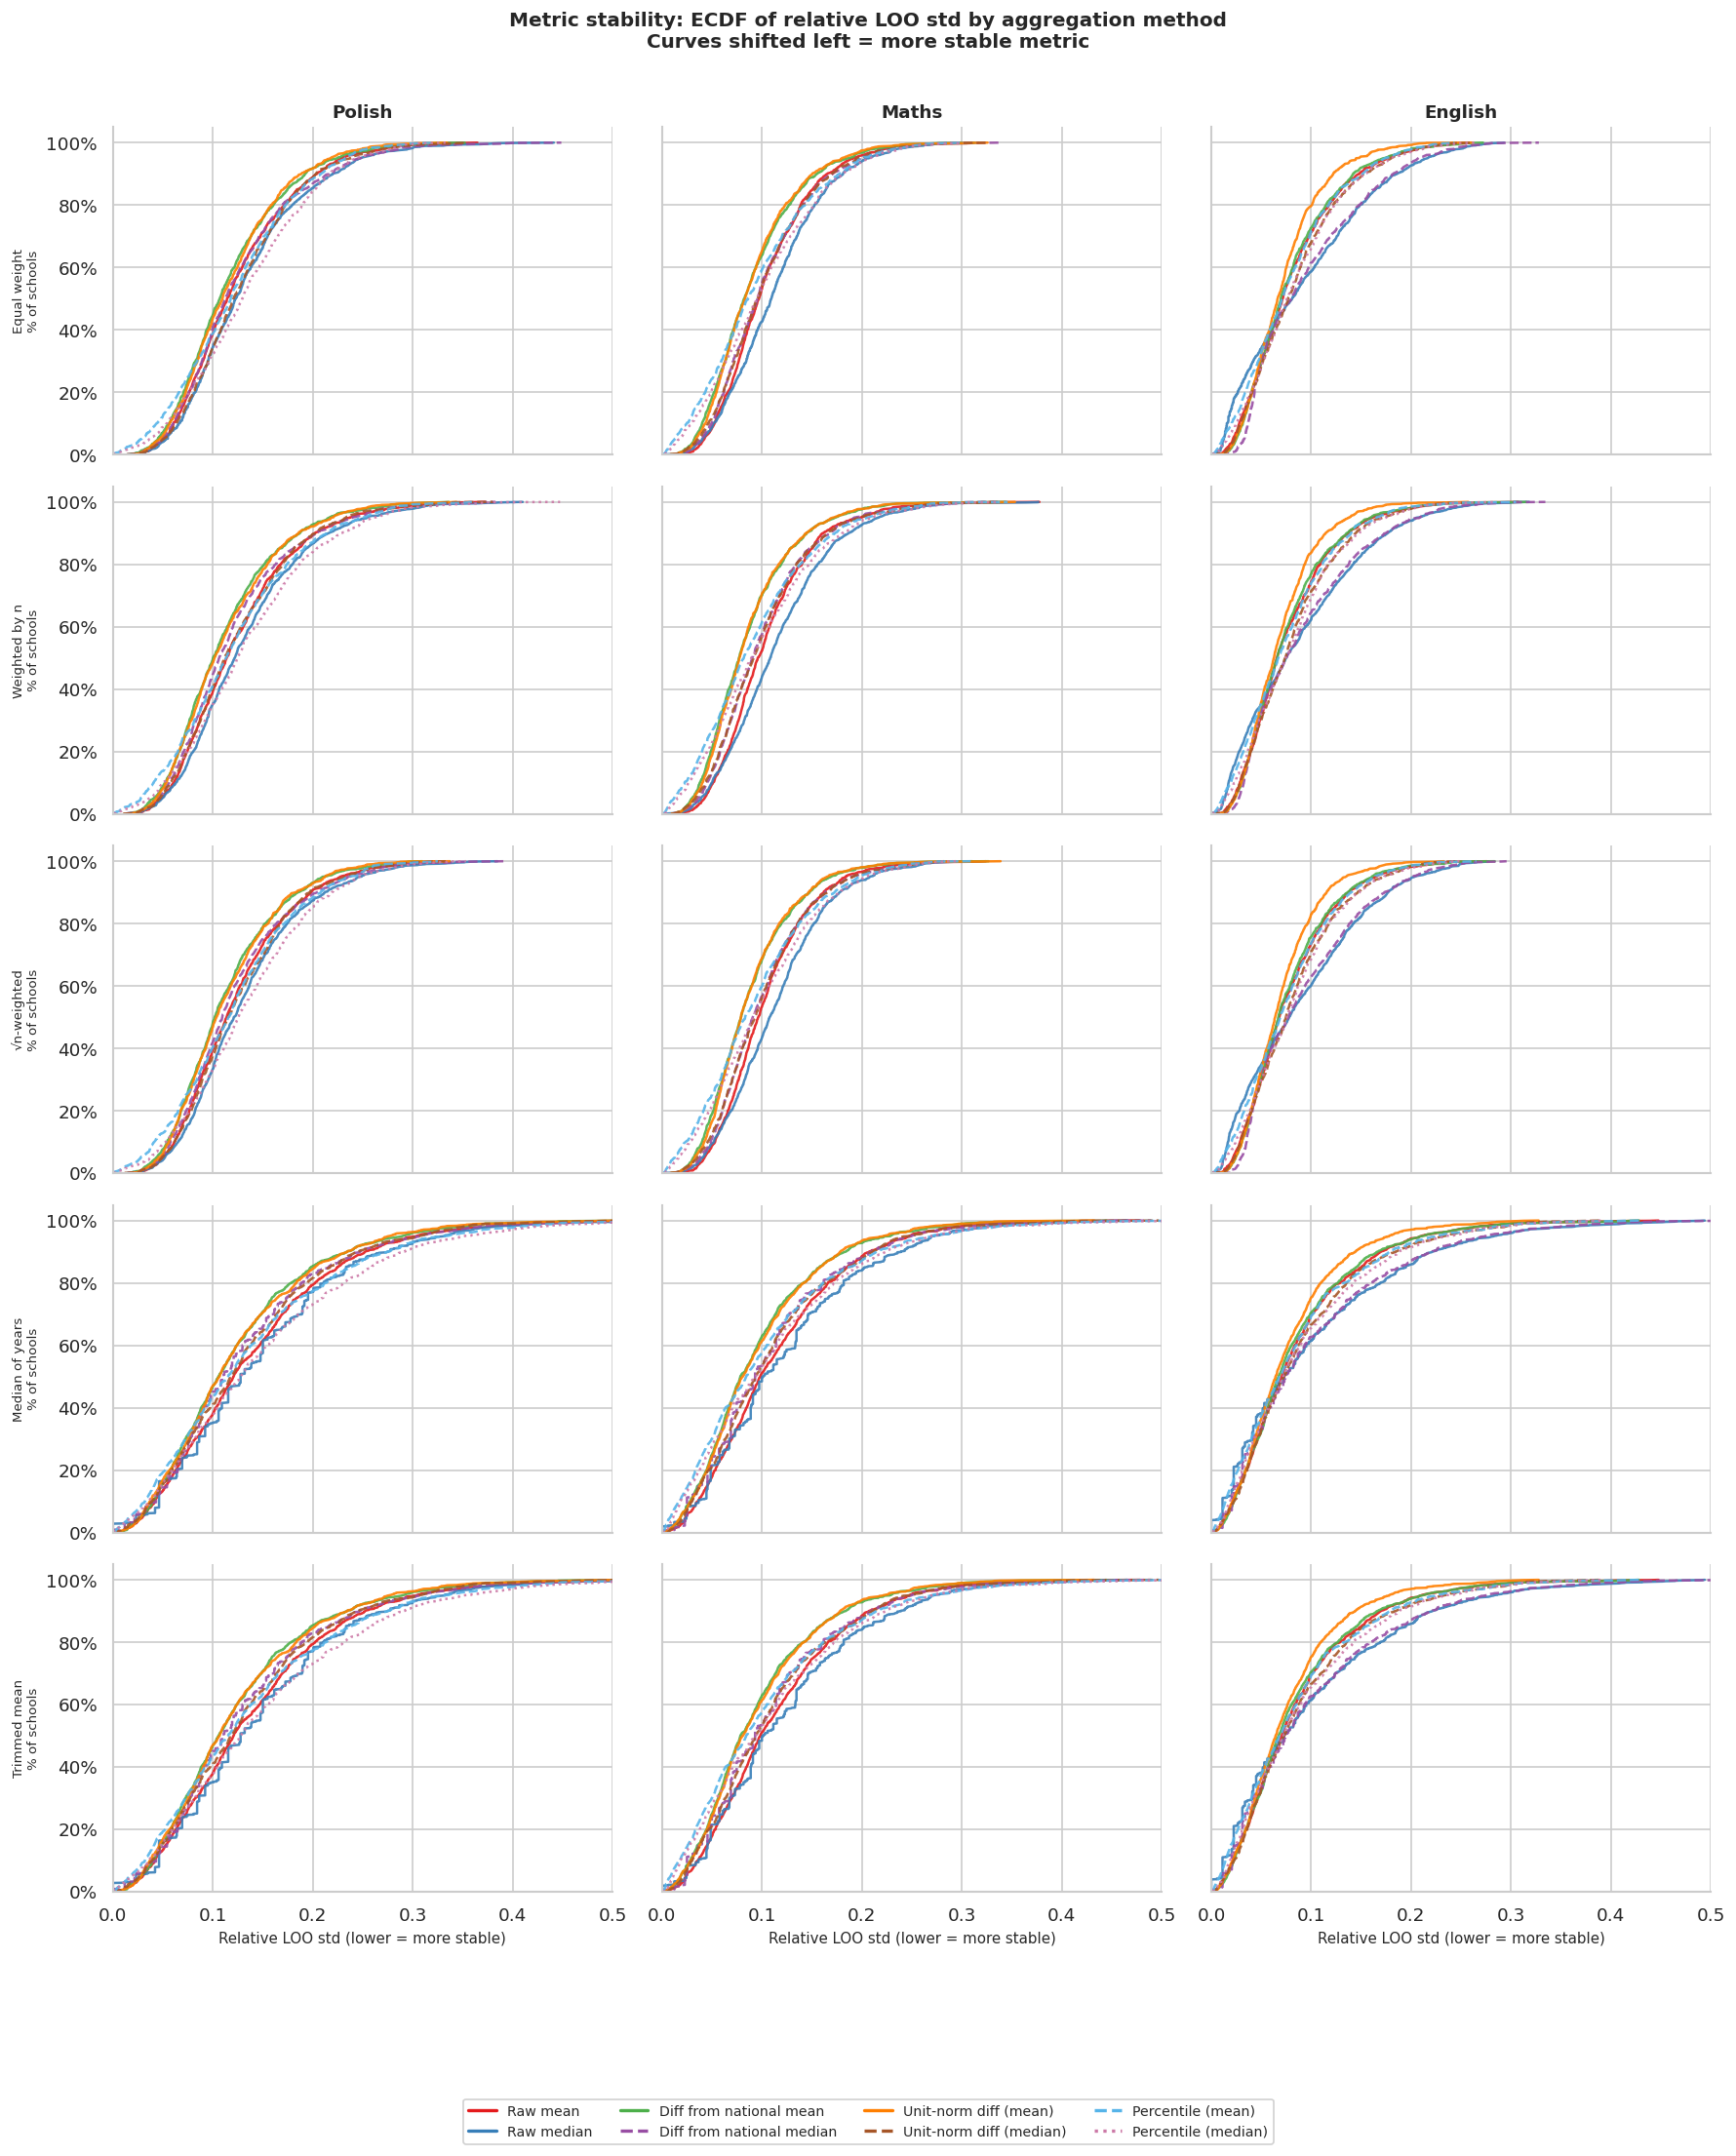

In [17]:
# ── ECDF of relative LOO std: 5 aggregation methods × 3 subjects ─────────────
METRIC_DISPLAY = {
    'mean':                  ('Raw mean',                    '#e41a1c', '-'),
    'median':                ('Raw median',                  '#377eb8', '-'),
    'diff_mean':             ('Diff from national mean',     '#4daf4a', '-'),
    'diff_median':           ('Diff from national median',   '#984ea3', '--'),
    'unit_norm_diff_mean':   ('Unit-norm diff (mean)',        '#ff7f00', '-'),
    'unit_norm_diff_median': ('Unit-norm diff (median)',      '#a65628', '--'),
    'pct_mean':              ('Percentile (mean)',            '#56b4e9', '--'),
    'pct_median':            ('Percentile (median)',          '#cc79a7', ':'),
}

AGG_METHOD_LABELS = {
    'mean':                                'Equal weight',
    'mean_weighted_by_students_count':     'Weighted by n',
    'mean_weighted_by_students_count_sqrt':'√n-weighted',
    'median':                              'Median of years',
    'trimmed_mean':                        'Trimmed mean',
}

fig, axes = plt.subplots(
    len(AGG_METHODS), len(core_short),
    figsize=(15, 3.5 * len(AGG_METHODS)),
    sharey=True, sharex=True,
)

for row_index, agg_method in enumerate(AGG_METHODS):
    agg_subset = loo_stability_df[loo_stability_df['aggregation_method'] == agg_method]
    for col_index, subject in enumerate(core_short):
        ax = axes[row_index, col_index]
        subject_subset = agg_subset[agg_subset['subject'] == subject]

        for metric_name, (label, color, linestyle) in METRIC_DISPLAY.items():
            relative_std_col = f'rel_{metric_name}'
            if relative_std_col not in subject_subset.columns:
                continue
            sorted_values = np.sort(subject_subset[relative_std_col].dropna().values)
            if len(sorted_values) == 0:
                continue
            cumulative_pct = np.arange(1, len(sorted_values) + 1) / len(sorted_values) * 100
            ax.plot(sorted_values, cumulative_pct, label=label,
                    color=color, lw=1.5, ls=linestyle, alpha=0.9)

        if row_index == 0:
            ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
        if col_index == 0:
            ax.set_ylabel(
                f'{AGG_METHOD_LABELS[agg_method]}\n% of schools',
                fontsize=8,
            )
            ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 105)
        ax.spines[['top', 'right']].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel('Relative LOO std (lower = more stable)', fontsize=9)

legend_handles = [
    mlines.Line2D([], [], color=color, lw=2, ls=linestyle, label=label)
    for label, color, linestyle in METRIC_DISPLAY.values()
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4, fontsize=8.5,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(
    'Metric stability: ECDF of relative LOO std by aggregation method\n'
    'Curves shifted left = more stable metric',
    fontsize=12, fontweight='bold', y=1.005,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [18]:
# ── Summary tables: LOO stability by size bin and overall ─────────────────────
rel_metric_cols = [f'rel_{m}' for m in METRIC_DISPLAY]

# Table A: per subject — rows = (size_bin, aggregation_method), cols = metric
for subject in core_short:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = loo_stability_df[loo_stability_df['subject'] == subject]

    size_agg_table = (
        subject_subset
        .groupby(['size_bin', 'aggregation_method'], observed=True)[rel_metric_cols]
        .median()
        .round(3)
    )
    size_agg_table.columns = list(METRIC_DISPLAY.keys())
    display(
        size_agg_table.style
        .set_uuid(f'loo_size_agg_{subject}')
        .highlight_min(axis=1, props='background-color: #c6efce !important; color: black !important;')
        .set_caption(
            f'{subject_label}: median relative LOO std by school size and aggregation method'
            ' (green = most stable metric in each row)'
        )
    )

# Table B: per subject — rows = metric, cols = aggregation_method
for subject in core_short:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = loo_stability_df[loo_stability_df['subject'] == subject]

    overall_records = []
    for metric_name in METRIC_DISPLAY:
        row = {'metric': metric_name}
        for agg_method in AGG_METHODS:
            agg_subset = subject_subset[subject_subset['aggregation_method'] == agg_method]
            row[AGG_METHOD_LABELS[agg_method]] = round(
                float(agg_subset[f'rel_{metric_name}'].median()), 3
            )
        overall_records.append(row)

    overall_table = pd.DataFrame(overall_records).set_index('metric')
    display(
        overall_table.style
        .set_uuid(f'loo_overall_{subject}')
        .highlight_min(axis=1, props='background-color: #c6efce !important; color: black !important;')
        .set_caption(
            f'{subject_label}: overall median relative LOO std per metric and aggregation method'
            ' (green = most stable aggregation for that metric)'
        )
    )


,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,0.114000,0.114000,0.114000,0.121000,0.121000
median,0.123000,0.122000,0.121000,0.128000,0.128000
diff_mean,0.107000,0.100000,0.102000,0.106000,0.106000
diff_median,0.113000,0.106000,0.109000,0.109000,0.109000
unit_norm_diff_mean,0.110000,0.102000,0.103000,0.107000,0.107000
unit_norm_diff_median,0.121000,0.112000,0.115000,0.119000,0.119000
pct_mean,0.118000,0.113000,0.116000,0.115000,0.115000
pct_median,0.129000,0.125000,0.126000,0.128000,0.128000


,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,0.097000,0.096000,0.096000,0.098000,0.098000
median,0.109000,0.108000,0.108000,0.101000,0.101000
diff_mean,0.082000,0.077000,0.079000,0.078000,0.078000
diff_median,0.096000,0.090000,0.091000,0.093000,0.093000
unit_norm_diff_mean,0.083000,0.077000,0.079000,0.081000,0.081000
unit_norm_diff_median,0.096000,0.092000,0.093000,0.093000,0.093000
pct_mean,0.086000,0.082000,0.083000,0.084000,0.084000
pct_median,0.095000,0.089000,0.091000,0.093000,0.093000


,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,0.072000,0.066000,0.068000,0.071000,0.071000
median,0.081000,0.075000,0.078000,0.073000,0.073000
diff_mean,0.070000,0.066000,0.067000,0.067000,0.067000
diff_median,0.080000,0.075000,0.077000,0.075000,0.075000
unit_norm_diff_mean,0.066000,0.063000,0.064000,0.064000,0.064000
unit_norm_diff_median,0.077000,0.074000,0.075000,0.073000,0.073000
pct_mean,0.071000,0.067000,0.069000,0.068000,0.068000
pct_median,0.076000,0.074000,0.076000,0.072000,0.072000


Schools with all 5 years: 1,140


Rank swing computed for 1,140 schools × 8 metrics × 3 subjects


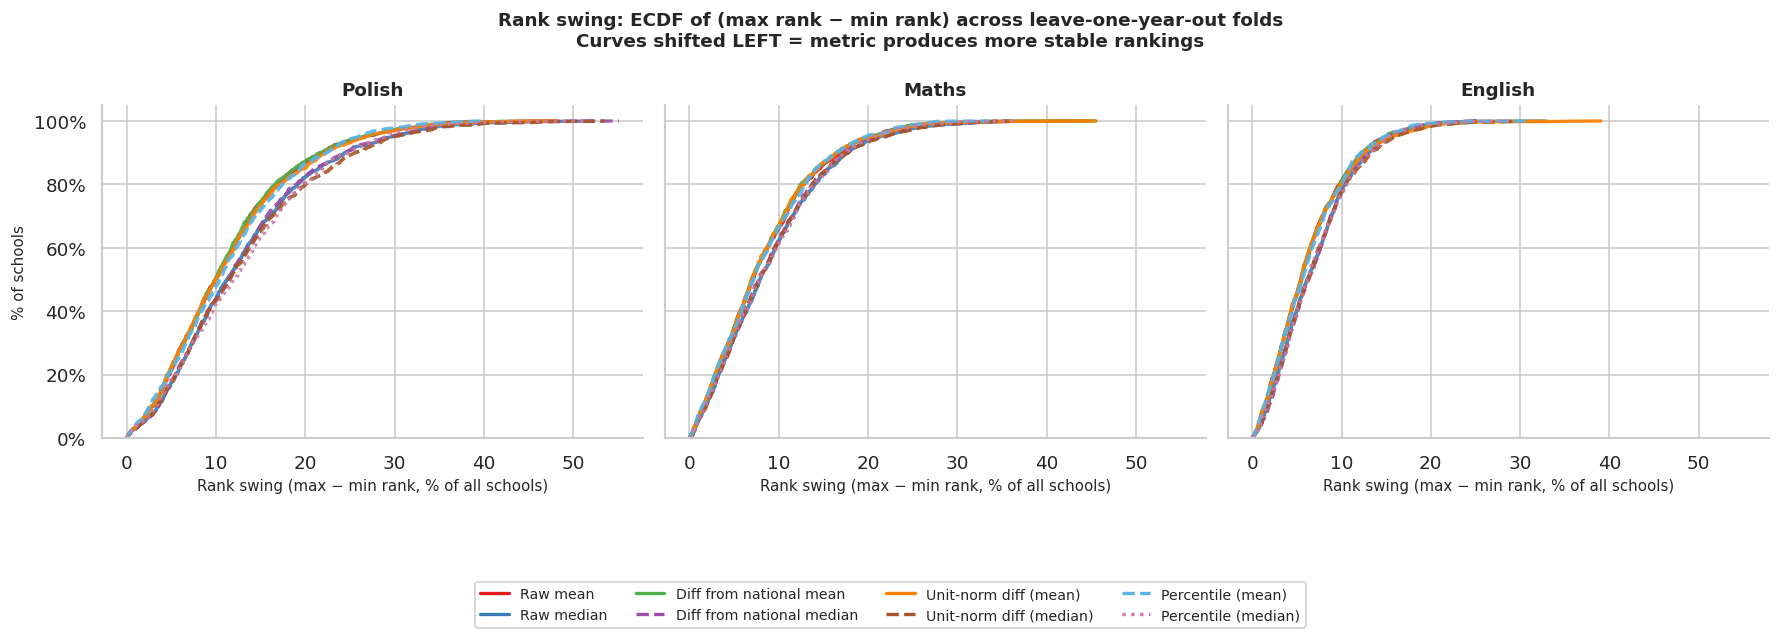

Median rank swing (% of schools) for — lower = more stable rankings:


metric,Raw mean,Raw median,Diff from national mean,Diff from national median,Unit-norm diff (mean),Unit-norm diff (median),Percentile (mean),Percentile (median)
1–9,13.900000,15.500000,12.200000,18.400000,12.500000,18.100000,13.600000,19.300000
10–19,12.100000,13.200000,12.200000,13.200000,12.500000,13.200000,12.500000,13.600000
20–49,11.000000,12.300000,10.400000,12.100000,10.400000,12.100000,11.000000,13.000000
50–99,8.700000,10.000000,8.700000,10.200000,8.600000,10.200000,9.000000,10.300000
100+,6.200000,7.800000,6.800000,7.600000,6.800000,8.200000,6.600000,8.600000


metric,Raw mean,Raw median,Diff from national mean,Diff from national median,Unit-norm diff (mean),Unit-norm diff (median),Percentile (mean),Percentile (median)
1–9,14.900000,17.600000,15.800000,17.800000,16.400000,18.400000,17.400000,17.300000
10–19,10.600000,10.600000,10.000000,10.900000,10.000000,11.000000,10.100000,11.700000
20–49,7.600000,8.900000,7.600000,8.600000,7.600000,8.700000,7.500000,8.800000
50–99,5.600000,6.400000,5.600000,6.200000,5.500000,6.100000,5.700000,6.200000
100+,4.000000,4.800000,4.100000,4.600000,4.200000,4.700000,4.100000,4.400000


metric,Raw mean,Raw median,Diff from national mean,Diff from national median,Unit-norm diff (mean),Unit-norm diff (median),Percentile (mean),Percentile (median)
1–9,14.600000,13.600000,14.900000,13.300000,16.300000,14.500000,14.400000,13.700000
10–19,8.400000,9.000000,8.600000,8.700000,8.200000,8.900000,8.200000,8.900000
20–49,6.200000,6.900000,6.200000,7.100000,6.100000,6.900000,6.400000,6.900000
50–99,4.200000,4.700000,4.200000,5.000000,4.300000,5.000000,4.500000,4.800000
100+,2.800000,3.100000,2.700000,3.300000,2.800000,3.200000,2.800000,3.200000


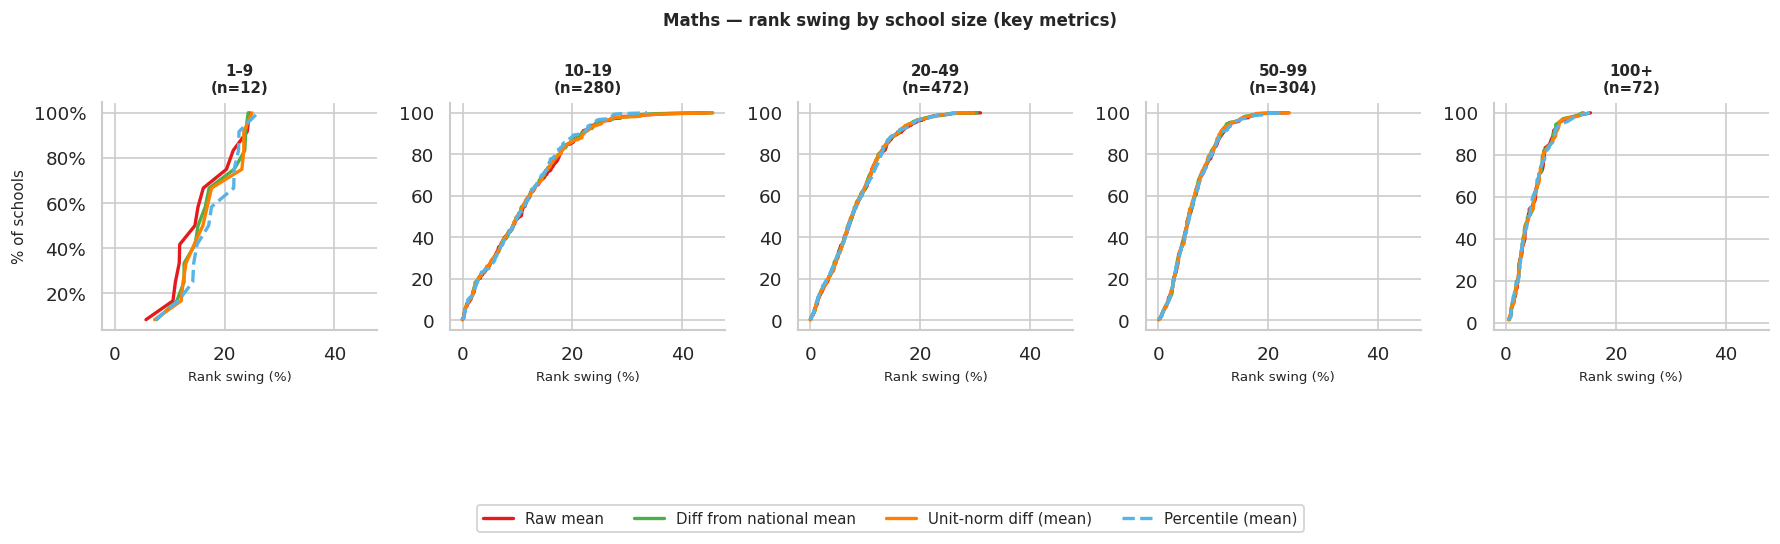

rank_swing_extended_df: 136,800 rows


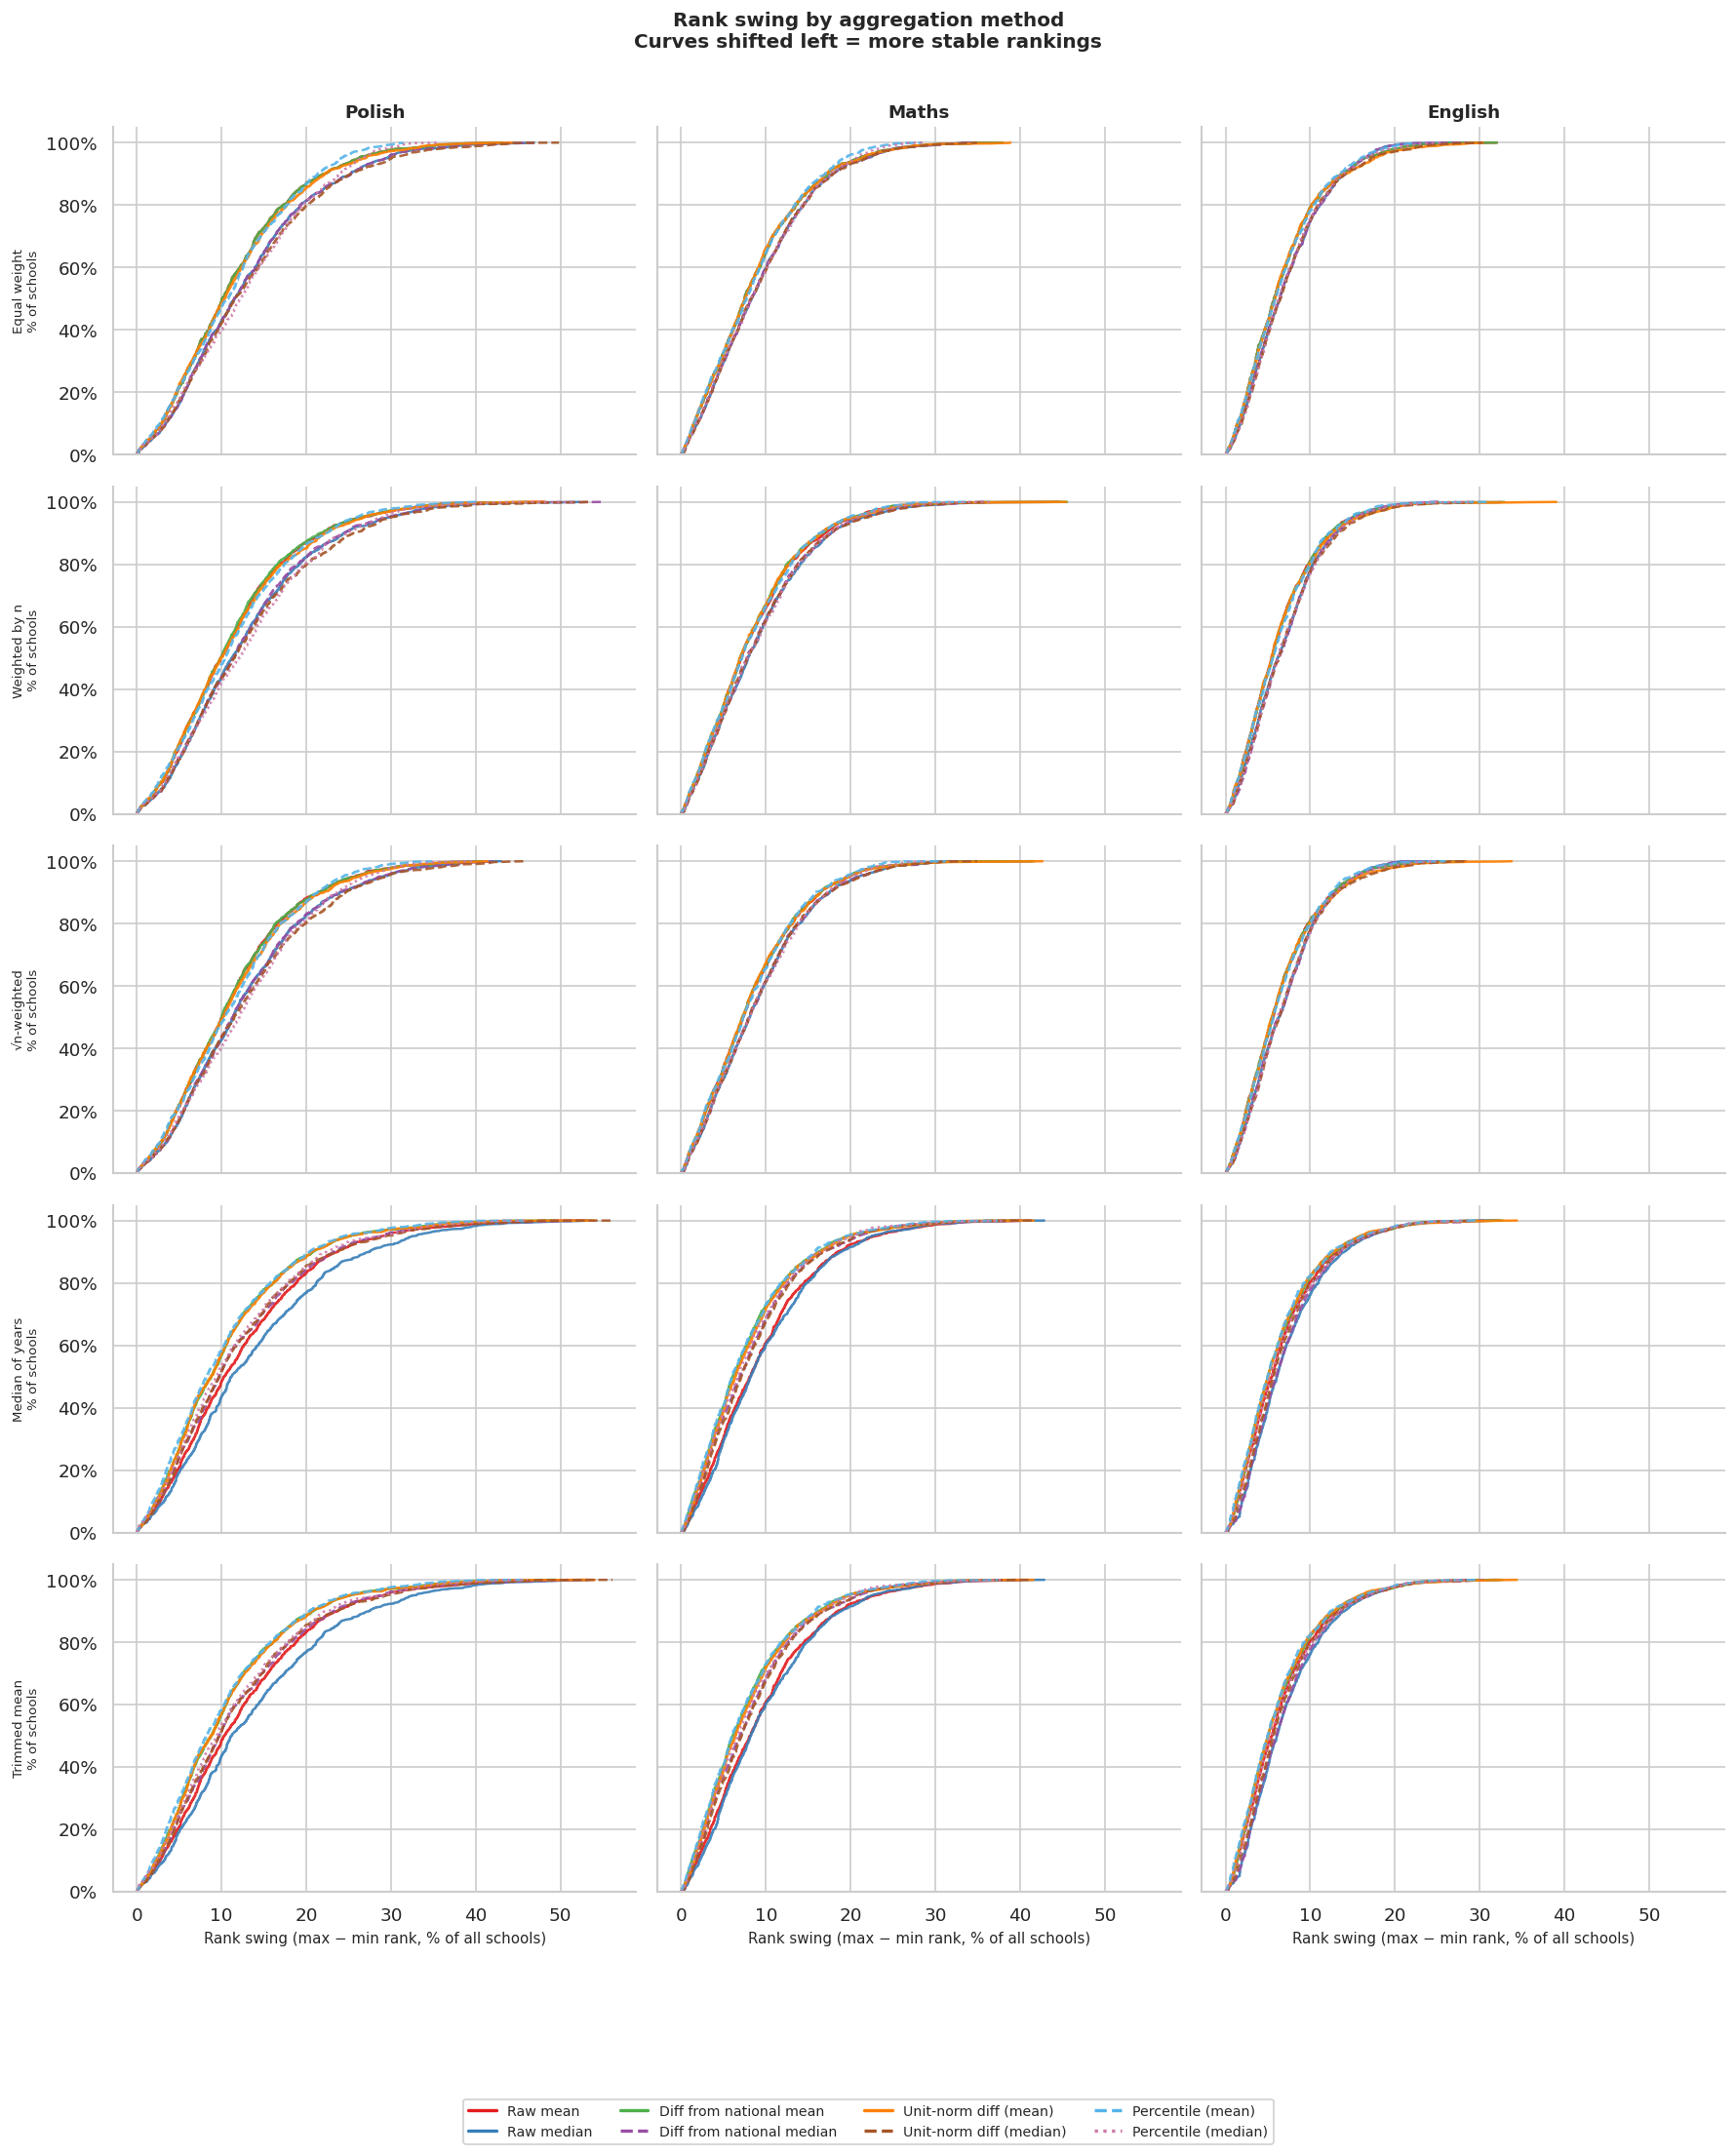

agg_method,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,10.100000,10.000000,10.000000,10.400000,10.400000
median,11.500000,11.300000,11.400000,11.200000,11.200000
diff_mean,10.100000,9.900000,10.000000,8.800000,8.800000
diff_median,11.500000,11.400000,11.400000,9.700000,9.700000
unit_norm_diff_mean,10.400000,10.000000,10.200000,8.800000,8.800000
unit_norm_diff_median,11.600000,11.500000,11.500000,9.800000,9.700000
pct_mean,10.800000,10.400000,10.400000,8.200000,8.200000
pct_median,12.300000,12.100000,12.100000,9.500000,9.500000


agg_method,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,7.500000,7.100000,7.300000,8.100000,8.100000
median,8.300000,7.900000,8.100000,8.200000,8.200000
diff_mean,7.500000,6.900000,7.200000,6.100000,6.100000
diff_median,8.300000,7.700000,8.000000,6.900000,6.900000
unit_norm_diff_mean,7.500000,6.900000,7.300000,6.400000,6.400000
unit_norm_diff_median,8.200000,7.800000,8.100000,7.100000,7.100000
pct_mean,7.700000,7.200000,7.400000,6.100000,6.100000
pct_median,8.200000,7.800000,8.100000,6.600000,6.700000


agg_method,Equal weight,Weighted by n,√n-weighted,Median of years,Trimmed mean
metric,,,,,
mean,5.700000,5.400000,5.600000,5.500000,5.500000
median,6.400000,6.100000,6.300000,6.100000,6.100000
diff_mean,5.700000,5.500000,5.500000,5.000000,5.000000
diff_median,6.400000,6.300000,6.300000,6.000000,6.000000
unit_norm_diff_mean,5.900000,5.400000,5.500000,5.000000,5.000000
unit_norm_diff_median,6.400000,6.300000,6.300000,5.700000,5.700000
pct_mean,5.900000,5.600000,5.600000,5.000000,5.000000
pct_median,6.300000,6.200000,6.100000,5.400000,5.400000


In [19]:
# ── Rank swing: how much does excluding one year shuffle school rankings? ─────
# For each fold position k (0 = exclude earliest year, etc.):
#   rank all schools that have fold position k → percentile in [0, 100].
# rank_swing = max percentile − min percentile across fold positions a school appears in.
# A metric with high LOO std should produce large rank swings — this cell verifies that.

# Only schools with data in every year have identical fold positions,
# so rankings are over the same population with the same excluded year.
# rspo_all_years and fold_scores_all_years are computed in earlier cells.
print(f'Schools with all {len(ALL_YEARS)} years: {len(rspo_all_years):,}')

# Compute rank swing per (school, subject, metric).
# All schools have identical fold positions: fold k = exclude the k-th year.
rank_swing_records = []
for subject in core_short:
    for metric_name in CANDIDATE_METRICS:
        school_fold_scores = fold_scores_all_years[(subject, metric_name)]
        if len(school_fold_scores) < 10:
            continue
        max_folds = max(len(scores) for scores in school_fold_scores.values())
        school_rank_pcts = {rspo: [] for rspo in school_fold_scores}
        for fold_position in range(max_folds):
            fold_rspos = [rspo for rspo, scores in school_fold_scores.items()
                          if fold_position < len(scores)]
            if len(fold_rspos) < 10:
                continue
            fold_scores_arr = np.array([school_fold_scores[rspo][fold_position]
                                        for rspo in fold_rspos])
            fold_rank_pcts = stats.rankdata(fold_scores_arr) / len(fold_rspos) * 100
            for rspo, rank_pct in zip(fold_rspos, fold_rank_pcts):
                school_rank_pcts[rspo].append(rank_pct)
        for rspo, rank_pcts in school_rank_pcts.items():
            if len(rank_pcts) < 2:
                continue
            rank_swing_records.append({
                'metric': metric_name, 'subject': subject, 'rspo': rspo,
                'rank_swing': max(rank_pcts) - min(rank_pcts),
                'mean_n': df.loc[df['rspo'] == rspo, f'n_{subject}'].mean(),
            })

rank_swing_df = pd.DataFrame(rank_swing_records)
rank_swing_df['size_bin'] = pd.cut(
    rank_swing_df['mean_n'], bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+'],
)
print(f'Rank swing computed for {rank_swing_df["rspo"].nunique():,} schools × '
      f'{len(CANDIDATE_METRICS)} metrics × {len(core_short)} subjects')

# ── Plot 1: ECDF of rank swing, all schools, per subject ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
for ax, subject in zip(axes, core_short):
    sub = rank_swing_df[rank_swing_df['subject'] == subject]
    for metric_name, (label, color, ls) in METRIC_DISPLAY.items():
        data = sub.loc[sub['metric'] == metric_name, 'rank_swing'].dropna().values
        if len(data) == 0:
            continue
        x = np.sort(data)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, label=label, color=color, lw=2, ls=ls, alpha=0.9)
    ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
    ax.set_xlabel('Rank swing (max − min rank, % of all schools)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of schools', fontsize=9)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
axes[0].set_ylim(0, 105)
handles = [mlines.Line2D([], [], color=c, lw=2, ls=ls, label=lbl)
           for lbl, c, ls in METRIC_DISPLAY.values()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8.5,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    'Rank swing: ECDF of (max rank − min rank) across leave-one-year-out folds\n'
    'Curves shifted LEFT = metric produces more stable rankings',
    fontsize=11, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

# ── Plot 2: Median rank swing table by size bin ──────────────────────
print('Median rank swing (% of schools) for — lower = more stable rankings:')
subject_swing = {}

for subject in core_short:
    subject_swing[subject] = rank_swing_df[rank_swing_df['subject'] == subject]
    swing_table = (
        subject_swing[subject].groupby(['size_bin', 'metric'], observed=True)['rank_swing']
        .median()
        .unstack('metric')
        .reindex(index=pd.CategoricalIndex(SIZE_BINS_ORDER, ordered=True))
    .reindex(columns=list(METRIC_DISPLAY.keys()))
    .rename(columns={m: lbl for m, (lbl, _, _) in METRIC_DISPLAY.items()})
    .round(1))
    display(swing_table.style.set_uuid('rank_swing_table').highlight_min(axis=1, color='#c6efce')
            .set_caption(f'{subject}: Green = metric with smallest median rank swing for that school size'))

# ── Plot 3: ECDF per size bin, Maths, key metrics ────────────────────────────
METRICS_FOR_SIZE_PLOT = ['mean', 'diff_mean', 'unit_norm_diff_mean', 'pct_mean']
fig, axes = plt.subplots(1, len(SIZE_BINS_ORDER), figsize=(15, 4), sharey=False, sharex=True)
for ax, size_bin in zip(axes, SIZE_BINS_ORDER):
    subject = 'matematyka'
    sub_bin = subject_swing[subject][subject_swing[subject]['size_bin'] == size_bin]
    n_in_bin = sub_bin['rspo'].nunique()
    for metric_name in METRICS_FOR_SIZE_PLOT:
        if metric_name not in METRIC_DISPLAY:
            continue
        label, color, ls = METRIC_DISPLAY[metric_name]
        data = sub_bin.loc[sub_bin['metric'] == metric_name, 'rank_swing'].dropna().values
        if len(data) < 5:
            continue
        x = np.sort(data)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, color=color, lw=2, ls=ls, label=label)
    ax.set_title(f'{size_bin}\n(n={n_in_bin})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Rank swing (%)', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('% of schools', fontsize=9)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
handles = [mlines.Line2D([], [], color=METRIC_DISPLAY[m][1], lw=2,
                          ls=METRIC_DISPLAY[m][2], label=METRIC_DISPLAY[m][0])
           for m in METRICS_FOR_SIZE_PLOT if m in METRIC_DISPLAY]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.12))
fig.suptitle('Maths — rank swing by school size (key metrics)', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0.16, 1, 1])
plt.show()

# ── Rank swing — extended: all aggregation methods × subjects × metrics ────────
# Mirrors the LOO std analysis: 5 aggregation methods × 3 subjects × 8 metrics.
# Extracts fold scores directly from loo_folds_df for all aggregation methods.

loo_extended = loo_folds_df[
    loo_folds_df['rspo'].isin(rspo_all_years)
    & (loo_folds_df['years'].apply(len) == len(ALL_YEARS) - 1)
].copy()
excluded_year_per_fold = loo_extended['years'].apply(
    lambda years_tuple: next(y for y in ALL_YEARS if y not in years_tuple)
)
loo_extended['fold_position'] = excluded_year_per_fold.map(
    {year: pos for pos, year in enumerate(ALL_YEARS)}
)

mean_n_by_rspo = (
    df[df['rspo'].isin(rspo_all_years)]
    .groupby('rspo')[[f'n_{s}' for s in core_short]]
    .mean()
)

rank_swing_extended_blocks = []
for agg_method in AGG_METHODS:
    agg_folds = loo_extended[loo_extended['aggregation_method'] == agg_method]
    for subject in core_short:
        for metric_name, getter in CANDIDATE_METRICS.items():
            col = getter(subject)
            pivot = (
                agg_folds[['rspo', 'fold_position', col]]
                .pivot_table(index='rspo', columns='fold_position', values=col)
                .dropna()
            )
            if len(pivot) < 10:
                continue
            rank_pct = pivot.rank() / len(pivot) * 100
            rank_swing_vals = rank_pct.max(axis=1) - rank_pct.min(axis=1)
            rank_swing_extended_blocks.append(pd.DataFrame({
                'rspo': rank_swing_vals.index,
                'rank_swing': rank_swing_vals.values,
                'agg_method': agg_method,
                'metric': metric_name,
                'subject': subject,
                'mean_n': mean_n_by_rspo.loc[rank_swing_vals.index, f'n_{subject}'].values,
            }))

rank_swing_extended_df = pd.concat(rank_swing_extended_blocks, ignore_index=True)
rank_swing_extended_df['size_bin'] = pd.cut(
    rank_swing_extended_df['mean_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=SIZE_BINS_ORDER,
)
print(f'rank_swing_extended_df: {len(rank_swing_extended_df):,} rows')

# ── ECDF: 5 aggregation methods × 3 subjects ─────────────────────────────────
fig, axes = plt.subplots(
    len(AGG_METHODS), len(core_short),
    figsize=(15, 3.5 * len(AGG_METHODS)),
    sharey=True, sharex=True,
)
for row_index, agg_method in enumerate(AGG_METHODS):
    agg_subset = rank_swing_extended_df[rank_swing_extended_df['agg_method'] == agg_method]
    for col_index, subject in enumerate(core_short):
        ax = axes[row_index, col_index]
        subject_subset = agg_subset[agg_subset['subject'] == subject]
        for metric_name, (label, color, linestyle) in METRIC_DISPLAY.items():
            data = subject_subset.loc[
                subject_subset['metric'] == metric_name, 'rank_swing'
            ].dropna().values
            if len(data) == 0:
                continue
            sorted_values = np.sort(data)
            cumulative_pct = np.arange(1, len(sorted_values) + 1) / len(sorted_values) * 100
            ax.plot(sorted_values, cumulative_pct, label=label,
                    color=color, lw=1.5, ls=linestyle, alpha=0.9)
        if row_index == 0:
            ax.set_title(SUBJECT_LABELS[subject], fontsize=11, fontweight='bold')
        if col_index == 0:
            ax.set_ylabel(
                f'{AGG_METHOD_LABELS[agg_method]}\n% of schools',
                fontsize=8,
            )
            ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
        ax.set_ylim(0, 105)
        ax.spines[['top', 'right']].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel('Rank swing (max − min rank, % of all schools)', fontsize=9)
legend_handles = [
    mlines.Line2D([], [], color=color, lw=2, ls=linestyle, label=label)
    for label, color, linestyle in METRIC_DISPLAY.values()
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4, fontsize=8.5,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(
    'Rank swing by aggregation method\nCurves shifted left = more stable rankings',
    fontsize=12, fontweight='bold', y=1.005,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ── Table A: per subject — rows = (size_bin, agg_method), cols = metric ───────
for subject in core_short:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = rank_swing_extended_df[rank_swing_extended_df['subject'] == subject]
    table = (
        subject_subset
        .groupby(['size_bin', 'agg_method', 'metric'], observed=True)['rank_swing']
        .median()
        .unstack('metric')
        .reindex(columns=list(METRIC_DISPLAY.keys()))
        .round(1)
    )
    display(
        table.style
        .set_uuid(f'rank_swing_size_agg_{subject}')
        .highlight_min(axis=1, props='background-color: #c6efce !important; color: black !important;')
        .set_caption(
            f'{subject_label}: median rank swing by school size and aggregation method'
            ' (green = most stable metric in each row)'
        )
    )

# ── Table B: per subject — rows = metric, cols = agg_method ───────────────────
for subject in core_short:
    subject_label = SUBJECT_LABELS[subject]
    subject_subset = rank_swing_extended_df[rank_swing_extended_df['subject'] == subject]
    table = (
        subject_subset
        .groupby(['metric', 'agg_method'], observed=True)['rank_swing']
        .median()
        .unstack('agg_method')
        .reindex(index=list(METRIC_DISPLAY.keys()))
        .rename(columns=AGG_METHOD_LABELS)
        .round(1)
    )
    display(
        table.style
        .set_uuid(f'rank_swing_overall_{subject}')
        .highlight_min(axis=1, props='background-color: #c6efce !important; color: black !important;')
        .set_caption(
            f'{subject_label}: overall median rank swing per metric and aggregation method'
            ' (green = most stable aggregation for that metric)'
        )
    )


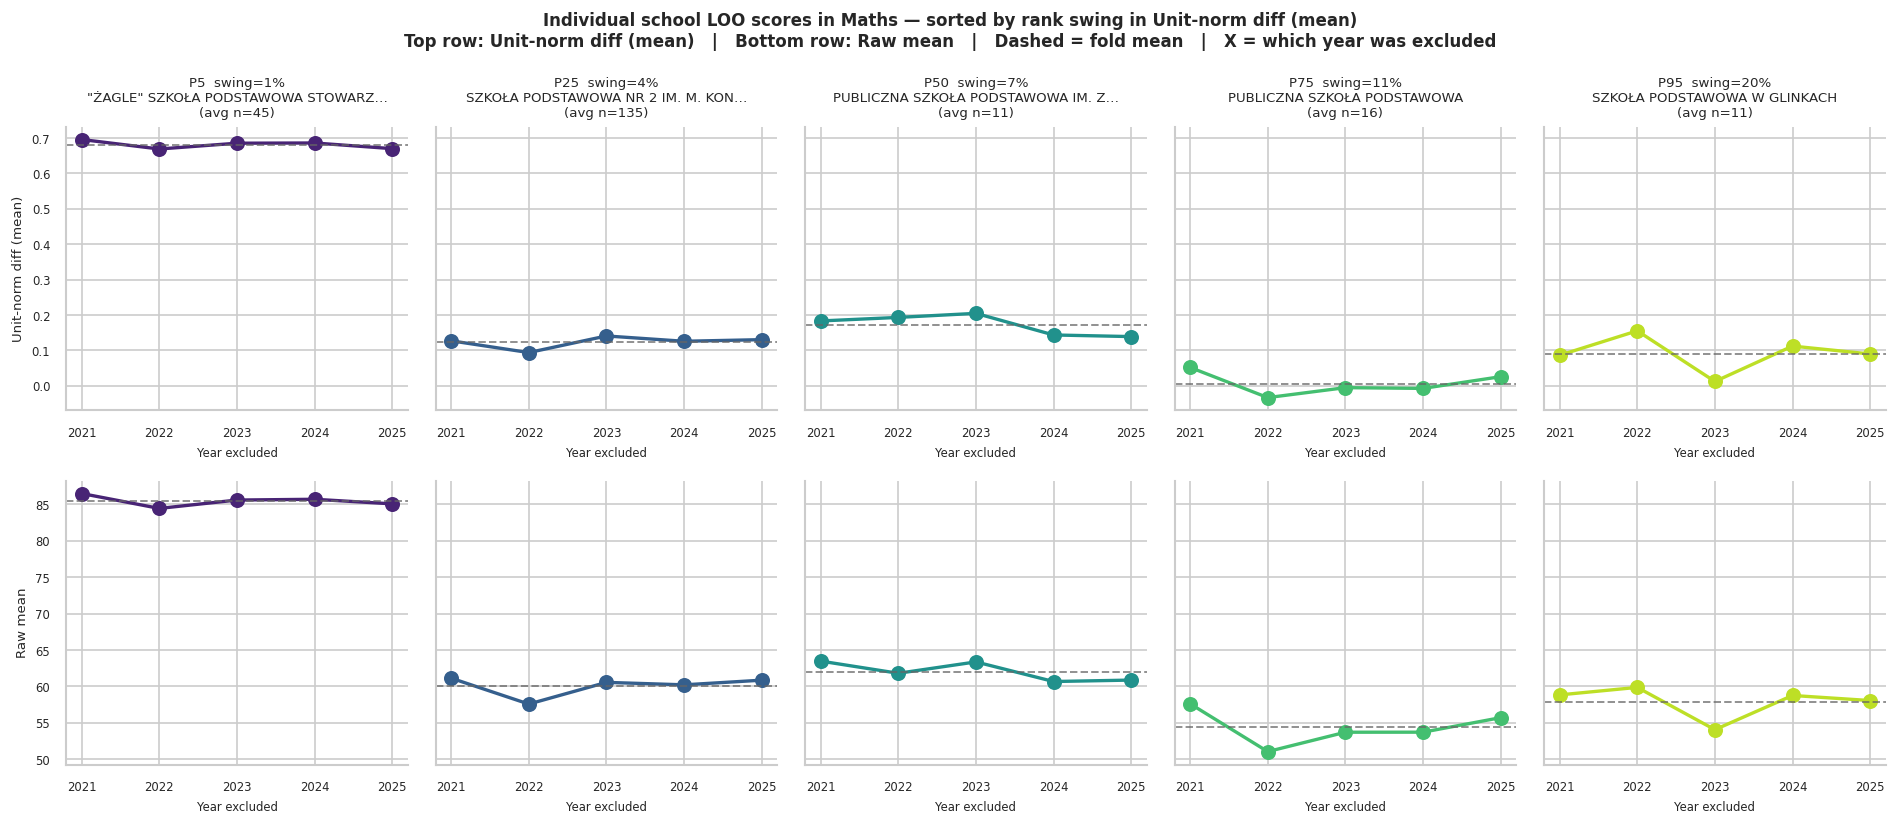

In [20]:
# ── Concrete examples: how stable is a school's LOO score when one year is excluded? ──
# Pick schools at different percentiles of rank swing for the primary metric (Maths).
# Each panel: score in LOO folds (X = excluded year, Y = score).
# Dashed horizontal = mean across folds. Tight cluster = stable; spread = unstable.
PRIMARY_SUBJECT  = 'matematyka'
PRIMARY_METRIC   = 'unit_norm_diff_mean'
BASELINE_METRIC  = 'mean'

swing_primary = (
    rank_swing_df[
        (rank_swing_df['metric'] == PRIMARY_METRIC) &
        (rank_swing_df['subject'] == PRIMARY_SUBJECT)
    ]
    .sort_values('rank_swing')
    .reset_index(drop=True)
)
PICK_PCTS = [5, 25, 50, 75, 95]

fig, axes = plt.subplots(2, len(PICK_PCTS), figsize=(16, 7), sharey='row')
school_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(PICK_PCTS)))

for col_idx, pct in enumerate(PICK_PCTS):
    idx = int(len(swing_primary) * pct / 100)
    row_data = swing_primary.iloc[idx]
    rspo, rank_swing_val = row_data['rspo'], row_data['rank_swing']
    school_name = df.loc[df['rspo'] == rspo, 'school_name'].iloc[0]
    name_short = school_name[:33] + '…' if len(school_name) > 33 else school_name
    avg_n = df.loc[df['rspo'] == rspo, f'n_{PRIMARY_SUBJECT}'].mean()
    school_years = sorted(df.loc[df['rspo'] == rspo, 'year'].unique())
    excluded_year_labels = [str(y) for y in school_years]

    for metric_row, metric_name in enumerate([PRIMARY_METRIC, BASELINE_METRIC]):
        ax = axes[metric_row, col_idx]
        fold_s = fold_scores_all_years[(PRIMARY_SUBJECT, metric_name)].get(rspo)
        if fold_s is None:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
            continue
        color = school_colors[col_idx]
        ax.plot(excluded_year_labels, fold_s, 'o-', lw=2, color=color, markersize=8)
        ax.axhline(np.mean(fold_s), ls='--', color='#666', lw=1.2, alpha=0.7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlabel('Year excluded', fontsize=7)
        if col_idx == 0:
            row_label = (METRIC_DISPLAY[metric_name][0]
                         if metric_name in METRIC_DISPLAY else metric_name)
            ax.set_ylabel(row_label, fontsize=8)
        if metric_row == 0:
            ax.set_title(
                f'P{pct}  swing={rank_swing_val:.0f}%\n{name_short}\n(avg n={avg_n:.0f})',
                fontsize=8,
            )

primary_label  = METRIC_DISPLAY.get(PRIMARY_METRIC,  (PRIMARY_METRIC,))[0]
baseline_label = METRIC_DISPLAY.get(BASELINE_METRIC, (BASELINE_METRIC,))[0]
fig.suptitle(
    f'Individual school LOO scores in {SUBJECT_LABELS[PRIMARY_SUBJECT]} — '
    f'sorted by rank swing in {primary_label}\n'
    f'Top row: {primary_label}   |   Bottom row: {baseline_label}   |   '
    f'Dashed = fold mean   |   X = which year was excluded',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
plt.show()


**Finding:** `diff_mean` and `unit_norm_diff_mean` are the most stable metrics across all
three subjects and all school sizes ≥ 10 students. The two correlate at Spearman 1.000
— they produce identical rankings, just with different scales. `diff_mean` is in
percentage points (interpretable: "5 pp above the voivodeship mean"); `unit_norm_diff_mean`
is in [-1, +1] (interpretable: "halfway between the voivodeship mean and the ceiling").

For very small schools (< 10 students) the differences between metrics shrink — all
metrics are noisy at that size because the sample is so small. The 0.15 pp gap visible
in the table is well within the sampling noise we documented above.

`diff_median` (using median) is consistently *worse* than `diff_mean`. This was a surprise:
our intuition was that the median should be more robust because it ignores outliers
within a school. But the analysis above showed that the median *jumps more* in
response to year-to-year difficulty changes, and that within-school medians swing
47-59% wider than means across years. The mean uses all student scores and is
empirically more stable.

We use **`unit_norm_diff_mean`** as the primary metric and expose `diff_mean` as a secondary
view in the app. The [-1, +1] scale is more stable across years than pp (sigma values
don't drift when new years are added) and supports a fixed-threshold colour scale
on the map.

## 4. Aggregating across years

We have up to 5 years of data per school. We need to combine them into one number.

Three natural options:
- **Weighted mean** — weight each year by the number of students sitting the exam
- **Median of years** — take the middle year's result (ignores how many students)
- **Trimmed mean** — drop the best and worst year, average the rest

We apply the same jackknife test: which aggregation gives the most stable
school score when we drop one year?

In [21]:
# For schools with 5 years of data: LOO stability of aggregation methods
# Use the winning per-year metric (unit_norm_diff_mean) as input
year_count_5 = df.groupby('rspo')['year'].nunique()
df5 = df[df['rspo'].isin(year_count_5[year_count_5 == 5].index)].copy()

aggregation_records = []
for rspo, grp in df5.groupby('rspo'):
    grp = grp.sort_values('year').reset_index(drop=True)
    for subject in core_short:
        n_vals = grp[f'n_{subject}'].values
        m_vals = grp[f'unit_norm_diff_mean_{subject}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(m_vals)):
            continue

        loo_wmean, loo_median, loo_trimmed = [], [], []
        for fold_index in range(5):
            mask = np.ones(5, dtype=bool); mask[fold_index] = False
            students_subset = n_vals[mask]; m_sub = m_vals[mask]; total_students = students_subset.sum()
            if total_students == 0: continue
            loo_wmean.append((students_subset * m_sub).sum() / total_students)
            loo_median.append(np.median(m_sub))
            loo_trimmed.append(np.sort(m_sub)[1:3].mean())  # 4 values → drop min/max, mean middle 2

        if len(loo_wmean) >= 4:
            aggregation_records.append({
                'rspo': rspo, 'subject': subject, 'mean_n': n_vals.mean(),
                'std_weighted_mean':      np.std(loo_wmean),
                'std_median_across_years': np.std(loo_median),
                'std_trimmed':    np.std(loo_trimmed),
            })

leave_one_out_aggregation = pd.DataFrame(aggregation_records)
leave_one_out_aggregation['size_bin'] = pd.cut(
    leave_one_out_aggregation['mean_n'], bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+'],
)

aggregation_summary = (
    leave_one_out_aggregation.groupby('size_bin', observed=True)[['std_weighted_mean', 'std_median_across_years', 'std_trimmed']]
    .median()
    .rename(columns={
        'std_weighted_mean':      'Weighted mean (by n)',
        'std_median_across_years': 'Median of years',
        'std_trimmed':    'Trimmed mean',
    }).round(3)
)
print('Median LOO std for aggregation methods (using unit_norm_diff_mean as input):')
display(aggregation_summary.style.set_uuid('aggregation_summary_table').highlight_min(axis=1, color='#c6efce')
        .set_caption('Green = most stable aggregation for that school size'))

Median LOO std for aggregation methods (using unit_norm_diff_mean as input):


,Weighted mean (by n),Median of years,Trimmed mean
size_bin,,,
1–9,0.040000,0.045000,0.045000
10–19,0.030000,0.030000,0.030000
20–49,0.023000,0.024000,0.024000
50–99,0.019000,0.021000,0.021000
100+,0.017000,0.016000,0.016000


**Finding:** Weighted mean (weighting each year by number of students)
is the most stable or tied-most-stable for all school sizes.
It also has the best intuitive justification: a year where 50 students sat the exam
should count more than a year where only 5 did.

**Final per-subject score formula:**
```
score(school, subject) = Σ(n_year × diff_year) / Σ(n_year)

where diff_year = school_median_year − voivodeship_median_year
```
This gives a number in percentage points: positive means above average for the country,
negative means below average, zero means exactly at the voivodeship median.

In [22]:
# ── Compute final per-subject score for every school ────────────────────────
# Primary metric: unit_norm_diff_mean.  Also export diff_mean, median, mean as alternatives.
PRIMARY_METRIC   = 'unit_norm_diff_mean'
SECONDARY_METRICS = ['diff_mean', 'median', 'mean']

score_records = []
for rspo, grp in df.groupby('rspo'):
    row = {
        'rspo':        rspo,
        'school_name': grp['school_name'].iloc[0],
        'is_public':   grp['is_public'].iloc[0],
        'n_years':     grp['year'].nunique(),
        'years':       sorted(grp['year'].unique().tolist()),
    }
    for subject in core_short:
        student_counts = pd.to_numeric(grp[f'n_{subject}'], errors='raise')
        valid = (student_counts > 0) & student_counts.notna()
        if valid.sum() == 0: continue
        n_arr = student_counts[valid].values
        total_students = n_arr.sum()

        for metric in [PRIMARY_METRIC] + SECONDARY_METRICS:
            col = f'{metric}_{subject}'
            if col not in grp.columns: continue
            m_arr = pd.to_numeric(grp[col], errors='raise')[valid].values
            if np.any(np.isnan(m_arr)): continue
            row[f'{metric}_{subject}'] = (n_arr * m_arr).sum() / total_students

        row[f'n_total_{subject}'] = int(total_students)
        row[f'n_years_{subject}'] = int(valid.sum())
    score_records.append(row)

scores = pd.DataFrame(score_records)
scores = scores.dropna(subset=[f'{PRIMARY_METRIC}_{s}' for s in core_short])

# Percentile ranks of the primary metric (for map colour)
for subject in core_short:
    col = f'{PRIMARY_METRIC}_{subject}'
    scores[f'pct_{subject}'] = (
        stats.rankdata(scores[col], method='average') / len(scores) * 100
    )

# Sigma per subject for colour scale
sigma = {subject: scores[f'{PRIMARY_METRIC}_{subject}'].std() for subject in core_short}
print(f'Sigma per subject (based on {PRIMARY_METRIC}):')
for subject in core_short:
    label_subj = SUBJECT_LABELS.get(subject, subject)
    print(f'  {label_subj:10s}: σ = {sigma[subject]:.4f}   '
          f'(saturate at ±{1.5 * sigma[subject]:.2f})')

print(f'\nSchools with scores: {len(scores):,}')

Sigma per subject (based on unit_norm_diff_mean):
  Polish    : σ = 0.1919   (saturate at ±0.29)
  Maths     : σ = 0.2843   (saturate at ±0.43)
  English   : σ = 0.3611   (saturate at ±0.54)

Schools with scores: 1,720


## 5. Which schools are consistently at the top?

Because individual years are noisy, we want to check that the top schools
are not just lucky — they should appear at the top across *multiple* LOO folds.

For each school we compute: how often does it appear in the top N
when we drop one year at a time? A school that is *always* in the top 30
is more trustworthy than one that is there only when one particular year is included.

In [23]:
# Jackknife stability of school ranking (Maths, schools with 5 years)
TOP_N_LIST = [5, 10, 30, 50]

def loo_scores(rspo_grp_iter, subject_code: str) -> dict:
    """Return {rspo: [score_loo_0, score_loo_1, ...]} for all schools."""
    result = {}
    for rspo, grp in rspo_grp_iter:
        grp = grp.sort_values('year').reset_index(drop=True)
        n_vals   = grp[f'n_{subject_code}'].values
        diff_vals= grp[f'diff_median_{subject_code}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(diff_vals)):
            continue
        year_count = len(grp)
        loos = []
        for fold_index in range(year_count):
            mask  = np.ones(year_count, dtype=bool); mask[fold_index] = False
            students_subset = n_vals[mask]; total_students = students_subset.sum()
            if total_students == 0: continue
            loos.append((students_subset * diff_vals[mask]).sum() / total_students)
        if loos:
            result[rspo] = loos
    return result


subject_code = 'matematyka'  # show for Maths; pattern is similar for other subjects
loo_vals = loo_scores(df5.groupby('rspo'), subject_code)

# For each LOO fold, rank all schools and record top-N membership
n_folds = 5
all_rspo = list(loo_vals.keys())

# Matrix: rows=schools, cols=folds, value=score
fold_matrix = pd.DataFrame(
    {rspo: {f: values[f] if f < len(values) else np.nan for f in range(n_folds)}
     for rspo, values in loo_vals.items()}
).T  # shape: (n_schools, 5)

consistency_rows = []
name_lu = df5.groupby('rspo')['school_name'].first()

for rspo in fold_matrix.index:
    row = {'rspo': rspo, 'school_name': name_lu.get(rspo, '?')}
    full_score = fold_matrix.loc[rspo].mean()  # mean across LOO folds ≈ full score
    row['mean_score'] = full_score
    for top_n in TOP_N_LIST:
        count_in_top = 0
        for fold in range(n_folds):
            fold_scores = fold_matrix[fold].dropna()
            rank = (fold_scores > fold_matrix.loc[rspo, fold]).sum() + 1
            if rank <= top_n:
                count_in_top += 1
        row[f'in_top_{top_n}_of_{n_folds}'] = count_in_top
    consistency_rows.append(row)

consistency = pd.DataFrame(consistency_rows).sort_values('mean_score', ascending=False)

print(f'Schools consistently in the top (Maths, schools with 5 years of data):')
display(
    consistency.head(40)[[
        'school_name', 'mean_score',
        f'in_top_5_of_{n_folds}', f'in_top_10_of_{n_folds}',
        f'in_top_30_of_{n_folds}', f'in_top_50_of_{n_folds}',
    ]].rename(columns={
        'mean_score':                'Avg score (pp above voivodeship)',
        f'in_top_5_of_{n_folds}':   f'In top 5 / {n_folds} folds',
        f'in_top_10_of_{n_folds}':  f'In top 10 / {n_folds} folds',
        f'in_top_30_of_{n_folds}':  f'In top 30 / {n_folds} folds',
        f'in_top_50_of_{n_folds}':  f'In top 50 / {n_folds} folds',
    }).style.set_uuid('top_schools_table').background_gradient(cmap='Greens', subset=[f'In top 5 / {n_folds} folds',
                                                         f'In top 10 / {n_folds} folds'])
)

Schools consistently in the top (Maths, schools with 5 years of data):


,school_name,Avg score (pp above voivodeship),In top 5 / 5 folds,In top 10 / 5 folds,In top 30 / 5 folds,In top 50 / 5 folds
1063,"SZKOŁA PODSTAWOWA PRZY SPOŁECZNYM LICEUM OGÓLNOKSZTAŁCĄCYM NR 4 IM. BATALIONU AK ""PARASOL""",43.591733,5,5,5,5
327,"PRYWATNA SZKOŁA PODSTAWOWA NR 81 FUNDACJI ""RODZICE DZIECIOM""",43.404227,5,5,5,5
244,PRYWATNA SZKOŁA PODSTAWOWA NR 6 SIÓSTR NIEPOKALANEK IM. BŁ. M. MARCELINY DAROWSKIEJ,43.369818,5,5,5,5
489,SZKOŁA PODSTAWOWA NR 3 PRZYMIERZA RODZIN IM. BŁOGOSŁAWIONEGO KS. JERZEGO POPIEŁUSZKI,42.674575,2,5,5,5
336,PRYWATNA SZKOŁA PODSTAWOWA NR 92,42.651022,3,5,5,5
347,PRYWATNA SZKOŁA PODSTAWOWA NR 51 IM. JANA BRZECHWY,42.623601,2,5,5,5
242,SPOŁECZNA SZKOŁA PODSTAWOWA NR 10 IM.KARDYNAŁA STEFANA WYSZYŃSKIEGO SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,42.186227,1,4,5,5
315,"NIEPUBLICZNA SZKOŁA PODSTAWOWA NR 47 IM. ROBERTA SCHUMANA FUNDACJI ""PRIMUS""",41.742176,0,4,5,5
338,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 100 SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,41.702871,0,2,5,5
305,SPOŁECZNA SZKOŁA PODSTAWOWA NR 16 SPOŁECZNEGOTOWARZYSTWA OŚWIATOWEGO,41.674884,1,2,5,5


## 6. Combining all three subjects

A school could score well in Maths but poorly in Polish. How do we combine
the three subject scores into a single number for the map?

First, we check how correlated the three subjects are.
If they are highly correlated, the choice of combination method barely matters.
If they are independent, we need to be careful.

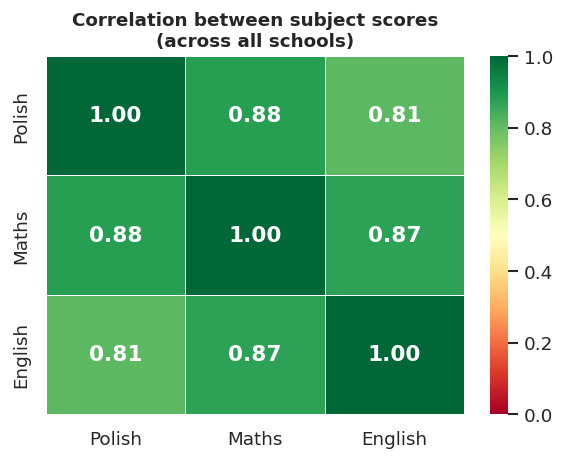


Spearman rank correlation (more robust to outliers):
         Polish  Maths  English
Polish     1.00   0.84     0.78
Maths      0.84   1.00     0.84
English    0.78   0.84     1.00


In [24]:
# ── Subject correlation ───────────────────────────────────────────────────────
score_cols = [f'unit_norm_diff_mean_{s}' for s in core_short]
corr = scores[score_cols].rename(
    columns={f'unit_norm_diff_mean_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('Correlation between subject scores\n(across all schools)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSpearman rank correlation (more robust to outliers):')
print(scores[score_cols].rename(
    columns={f'unit_norm_diff_mean_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr(method='spearman').round(2))

Schools good in all 3 subjects (≥60th percentile each): 496
  of which public:   332
  of which private:  164


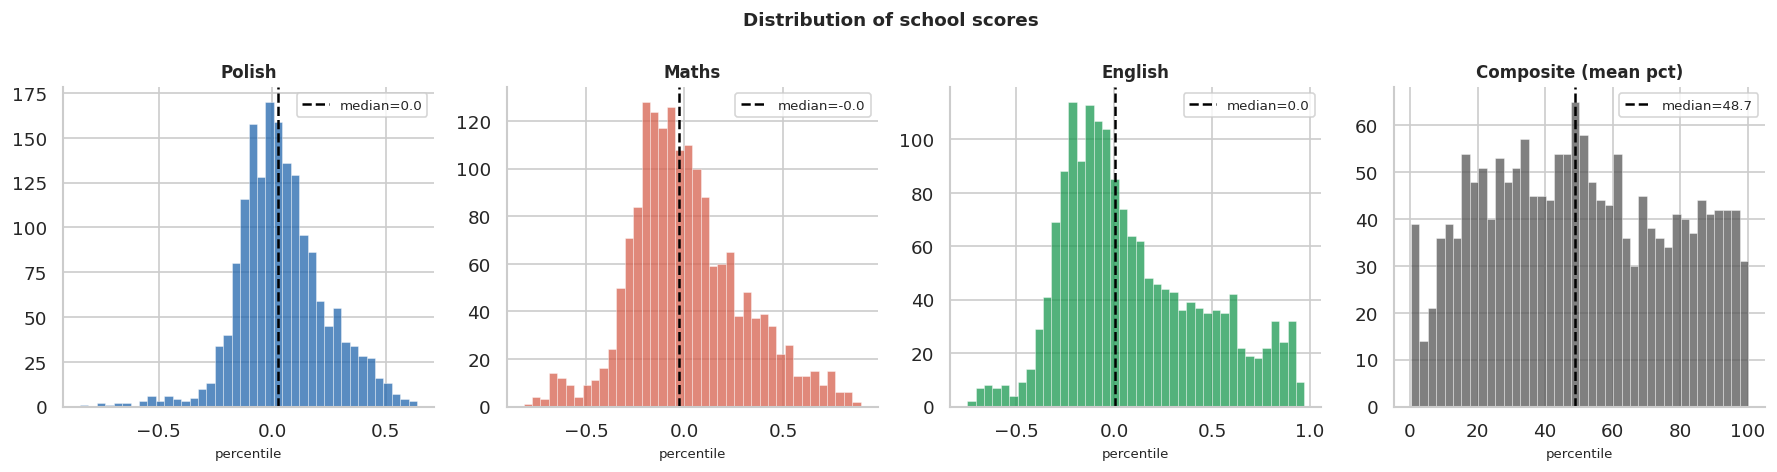

In [25]:
# ── Composite score: mean of per-subject percentiles ─────────────────────────
scores['composite_percentile'] = scores[[f'pct_{s}' for s in core_short]].mean(axis=1)

scores['good_in_all_3'] = (
    (scores['pct_polski']    >= 60) &
    (scores['pct_matematyka']>= 60) &
    (scores['pct_angielski'] >= 60)
)

print(f'Schools good in all 3 subjects (≥60th percentile each): {scores["good_in_all_3"].sum()}')
print(f'  of which public:   {(scores["good_in_all_3"] & (scores["is_public"]=="Tak")).sum()}')
print(f'  of which private:  {(scores["good_in_all_3"] & (scores["is_public"]=="Nie")).sum()}')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

subjects_to_plot = [
    (f'unit_norm_diff_mean_{s}', SUBJECT_LABELS.get(s, s), SUBJECT_COLORS[s])
    for s in core_short
]
subjects_to_plot.append(('composite_percentile', 'Composite (mean pct)', '#555555'))

for ax, (col, label, color) in zip(axes, subjects_to_plot):
    data = scores[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(data.median(), color='black', lw=1.5, ls='--', label=f'median={data.median():.1f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('pp above/below voivodeship' if 'score' in col else 'percentile', fontsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of school scores', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Final metric definition

Based on the analysis above, here is the metric used for the school quality map.

### Per-subject score

```
diff_year(school, subject, year) =
    median_score(school, subject, year) − voivodeship_median(subject, year)

score(school, subject) =
    Σ_year [ n_students(year) × diff_year ] / Σ_year [ n_students(year) ]
```

This gives a number in percentage points:
- **+10 pp** means the middle student at this school scores 10 points above
  the middle student voivodeshiply, averaged over all available years.
- **−5 pp** means the school is below average by 5 points.

### Why this metric?

1. **Difference from voivodeship median** removes the year-difficulty effect
   (the 14 pp swing in Maths difficulty between 2021 and 2022 is neutralised).
2. **Median** is preferred over mean because outlier students
   (one gifted or one struggling child) affect the mean more than the median.
3. **Weighted by student count** means a year with 50 students carries
   more weight than a year with 5, which is statistically correct.
4. The metric is **not a percentile** — a school 10 pp above average gets that
   number regardless of whether 300 or 3 other schools are also around that level.
   Percentile is used only for colouring the map markers.

### Map colour scale

The marker colour on the map is a diverging green–yellow–red gradient:
- **Yellow** = within ±0.33σ of the voivodeship median (not meaningfully different)
- **Deep green** = ≥ +1.5σ above voivodeship (reliably excellent)
- **Deep red** = ≤ −1.5σ below voivodeship (reliably weak)

Schools far above +1.5σ all get the same deep green — they are all excellent,
and the difference between them is within statistical noise given the sample sizes.

### Composite score

The map also shows a composite score: the mean of the three subject percentile ranks.
Schools flagged as **good in all 3** (≥60th percentile in each subject)
are highlighted separately — this is the most conservative indicator of
all-round quality.

In [26]:
# ── Export for the map ────────────────────────────────────────────────────────
# Primary metric: unit_norm_diff_mean.  Also export diff_mean, mean, median for app toggle.
import json as _json

export_cols = ['rspo', 'school_name', 'is_public', 'n_years']
for subject in core_short:
    export_cols += [
        f'unit_norm_diff_mean_{subject}',  # primary
        f'diff_mean_{subject}',       # alternate scale (pp)
        f'median_{subject}',         # baseline 1
        f'mean_{subject}',           # baseline 2
        f'pct_{subject}',            # percentile of primary
        f'n_total_{subject}',
        f'n_years_{subject}',
    ]
export_cols += ['composite_percentile', 'good_in_all_3']

export = scores[[c for c in export_cols if c in scores.columns]].copy()

# Sigma thresholds (used by the map for colour saturation)
sigma_export = {f'sigma_unit_norm_diff_mean_{s}': round(sigma[s], 4) for s in core_short}
for s in core_short:
    sigma_export[f'sigma_diff_mean_{s}'] = round(scores[f'diff_mean_{s}'].std(), 2)

print('Sigma values for map colour scale:')
for key, value in sigma_export.items():
    print(f'  {key}: {value}')

out_path = Path('../data/school_scores.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
export.to_csv(out_path, index=False)
print(f'\nExported {len(export):,} schools to {out_path}')

sigma_path = Path('../data/sigma_thresholds.json')
sigma_path.write_text(_json.dumps(sigma_export, indent=2, ensure_ascii=False))
print(f'Exported sigma thresholds to {sigma_path}')

display(export.head(3))

Sigma values for map colour scale:
  sigma_unit_norm_diff_mean_polski: 0.1919
  sigma_unit_norm_diff_mean_matematyka: 0.2843
  sigma_unit_norm_diff_mean_angielski: 0.3611
  sigma_diff_mean_polski: 9.19
  sigma_diff_mean_matematyka: 14.01
  sigma_diff_mean_angielski: 15.87

Exported 1,720 schools to ../data/school_scores.csv
Exported sigma thresholds to ../data/sigma_thresholds.json


,rspo,school_name,is_public,n_years,unit_norm_diff_mean_polski,diff_mean_polski,median_polski,mean_polski,pct_polski,n_total_polski,...,n_years_matematyka,unit_norm_diff_mean_angielski,diff_mean_angielski,median_angielski,mean_angielski,pct_angielski,n_total_angielski,n_years_angielski,composite_percentile,good_in_all_3
0,2880,PUBLICZNA SZKOŁA PODSTAWOWA IM. JANA BRZECHWY ...,Tak,4,0.093892,3.283387,72.277778,68.166667,65.290698,36,...,4,0.096759,0.669156,70.942857,67.400000,59.651163,35,4,57.325581,False
1,2970,NIEPUBLICZNA SZKOŁA PODSTAWOWA W GOŁĄBKU,Nie,2,0.061272,1.080553,64.250000,63.666667,59.186047,12,...,2,0.089045,0.422044,67.750000,66.916667,58.837209,12,2,64.263566,False
2,2985,SZKOŁA PODSTAWOWA W LIPNIE,Tak,1,-0.052123,-3.213801,60.000000,58.444444,31.511628,9,...,1,-0.308915,-20.434272,27.000000,45.714286,8.313953,7,1,23.856589,False
